# Plotting Notebook
Please use this is a guide to the type plots that you can create, as examples of the `hist`, `mplhep`, and other packages, as well as the use of the various functions that we have written in `plot_utils.py`. <br>
Use the the Table of Contents in Jupyter to view the different sections of the notebook to help navigating it.

In [1]:
%load_ext autoreload

In [60]:
%autoreload 1

In [61]:
import os, sys, glob, random
import pickle
import math
import multiprocessing
import itertools
import warnings
import json
import time
import numpy as np
from typing import Dict, List
from rich import print
from rich.pretty import pprint
from rich.console import Console
from rich.table import Table
from rich.progress import Progress, track
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
from cycler import cycler
import hist
from hist import Hist
import mplhep as hep
from tabulate import tabulate
import scipy
from scipy.special import binom
import uproot
import ROOT
from iminuit import Minuit
from iminuit.cost import LeastSquares
from jacobi import propagate
%aimport plot_utils
%aimport plot_utils_extras
%aimport fill_utils
%aimport generic_utils

In [62]:
warnings.filterwarnings('ignore')
mpl.rcParams.update({'figure.max_open_warning': 0})
mpl.rcParams['figure.facecolor'] = 'white'
hep.style.use("CMS")
np.set_printoptions(suppress=True)

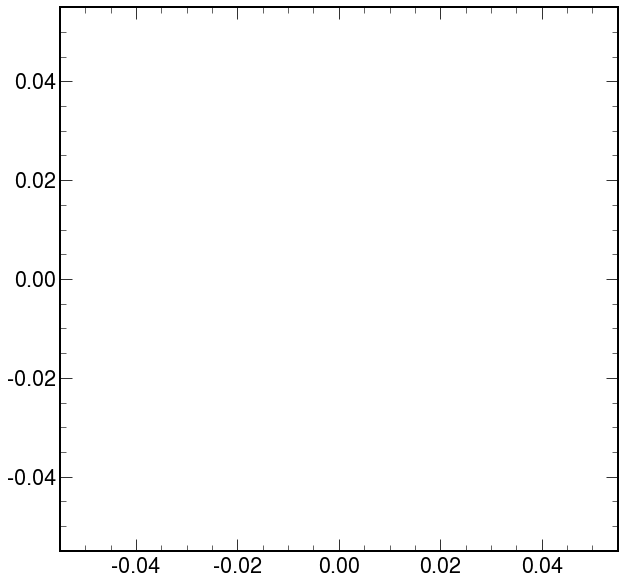

In [63]:
plt.plot()
hep.style.use(hep.style.CMS)
mpl.rcParams['figure.facecolor'] = 'white'

In [64]:
print("The following output directories are available:")
!ls | grep output_histograms

The following output directories are available:

CR_cb_34mu_output_histograms
CR_cb_combine_output_histograms
CR_cb_output_histograms
CR_cb_postDYstudy_output_histograms
CR_light_postDYstudy_output_histograms
CR_prompt_34mu_leading_output_histograms
CR_prompt_34mu_output_histograms
CR_prompt_combine_output_histograms
CR_prompt_dimuon_output_histograms
CR_prompt_dystudy_output_histograms
CR_prompt_leading_output_histograms
CR_prompt_output_histograms
CR_prompt_postDYstudy_output_histograms
DYstudy_2_output_histograms
DYstudy_3_output_histograms
DYstudy_4_output_histograms
DYstudy_5_output_histograms
DYstudy_output_histograms
DYstudy_trigger_match_double_output_histograms
DYstudy_trigger_match_triple_output_histograms
DYstudy_trigger_one_path_output_histograms
fake_rate_output_histograms
gen_bug_comparisons_output_histograms
high_temp_output_histograms
kinematics_output_histograms
nbjet_comparison_output_histograms
post_gensum_bug_output_histograms
SR_combine_new_trigger_output_histograms
SR_combine_old_trigger_output_histograms
SR_com

## Load plots

In [65]:
plots_CR = generic_utils.loader(tag="SR_high_temp_CR")
plots_SR = generic_utils.loader(tag="SR_high_temp_SR")
plots = {}
for dataset in plots_CR:
    plots[dataset] = plots_CR[dataset] | plots_SR[dataset] # Note: this merges two dicts!

These are all the samples loaded.

In [49]:
keys = list(plots.keys())
pprint(keys)

[
│   'GluGluToSUEP_mS1000.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS1000.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS1000.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS1000.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS200.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS200.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS200.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS200.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS300.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS300.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS300.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS300.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS400.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS400.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS400.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS400.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS500.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS500.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS500.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS500.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS600.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS600.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS600.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS600.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS800.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS800.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
│   'GluGluToSUEP_mS800.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
│   'GluGluToSUEP_mS800.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
│   'DYLowMass_NLO_2018',
│   'DYJetsToLL_NLO_2018',
│   'QCD_Pt-1000_MuEnrichedPt5_TuneCP5_13TeV-pythia8+RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v2+NANOAODSIM_histograms_2018',
│   'QCD_Pt_MuEnriched_2018',
│   'QCD_Pt-120To170_MuEnrichedPt5_TuneCP5_13TeV-pythia8+RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v2+NANOAODSIM_histograms_2018',
│   'QCD_Pt-15To20_MuEnrichedPt5_TuneCP5_13TeV-pythia8+RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v2+NANOAODSIM_histograms_2018',
│   'QCD_Pt-170To300_MuEnrichedPt5_TuneCP5_13TeV-pythia8+RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v2+NANOAODSIM_histograms_2018',
│   'QCD_Pt-20To30_MuEnrichedPt5_TuneCP5_13TeV-pythia8+RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v2+NANOAODSIM_histograms_2018',
│   'QCD_Pt-300To470_MuEnrichedPt5_TuneCP5_13TeV-pythia8+RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v2+NANOAODSIM_histograms_2018',
│   'QCD_Pt-30To50_MuEnrichedPt5_TuneCP5_13TeV-pythia8+RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v2+NANOAODSIM_histograms_2018',
│   'QCD_Pt-470To600_MuEnrichedPt5_TuneCP5_13TeV-pythia8+RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v2+NANOAODSIM_histograms_2018',
│   'QCD_Pt-50To80_MuEnrichedPt5_TuneCP5_13TeV-pythia8+RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v2+NANOAODSIM_histograms_2018',
│   'QCD_Pt-600To800_MuEnrichedPt5_TuneCP5_13TeV-pythia8+RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v2+NANOAODSIM_histograms_2018',
│   'QCD_Pt-800To1000_MuEnrichedPt5_TuneCP5_13TeV-pythia8+RunIISummer20UL18NanoAODv9-106X_upgrade20

In [50]:
for key in plots['QCD_Pt_MuEnriched_2018'].keys():
    pprint(f"{key}")

'CR_prompt'

'CR_light'

'CR_cb'

'SR_high_temp_tight'

'SR_high_temp_loose'

## Plot stack of bkgs for nMuon distribution

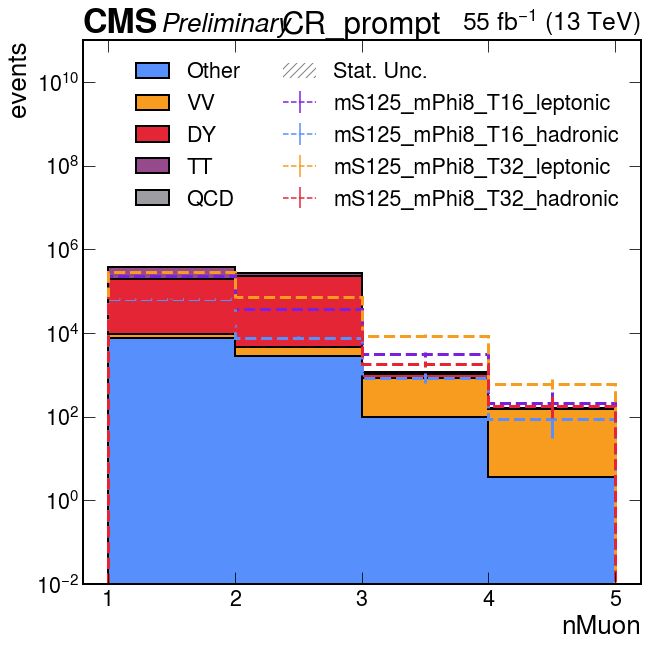

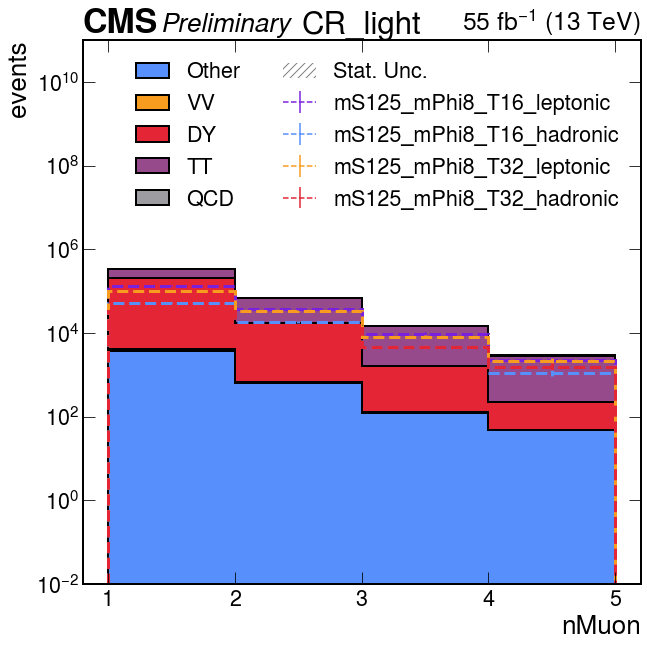

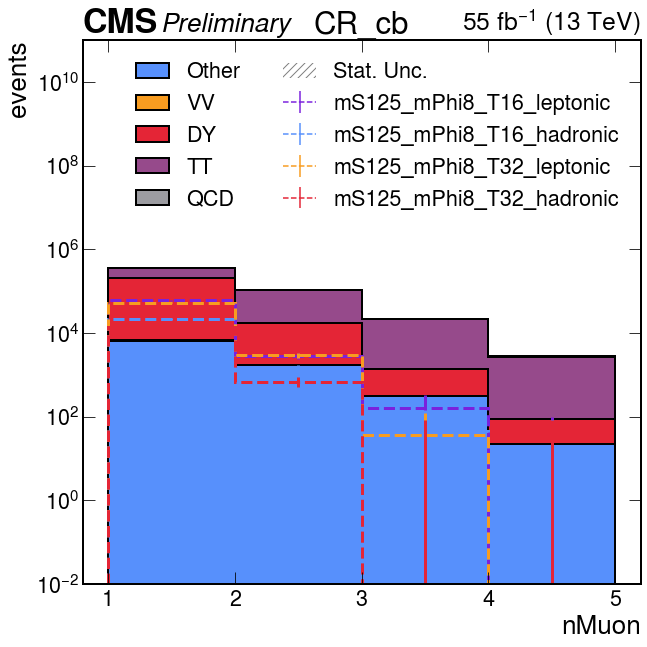

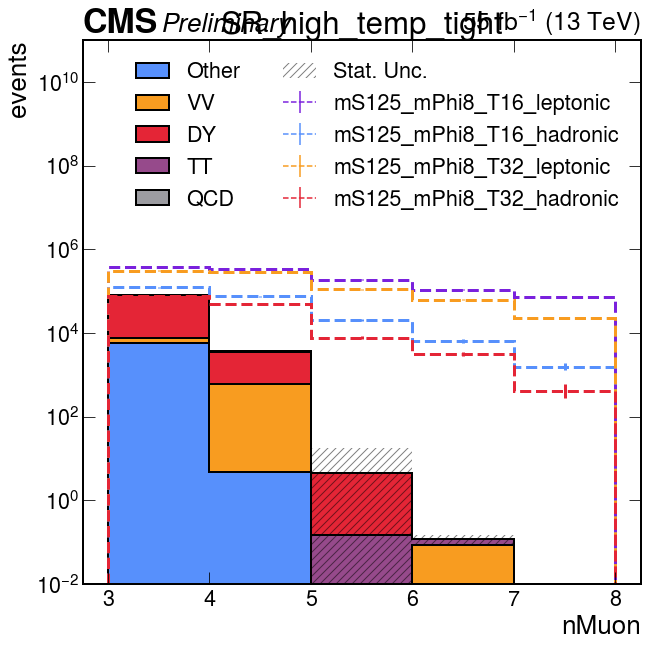

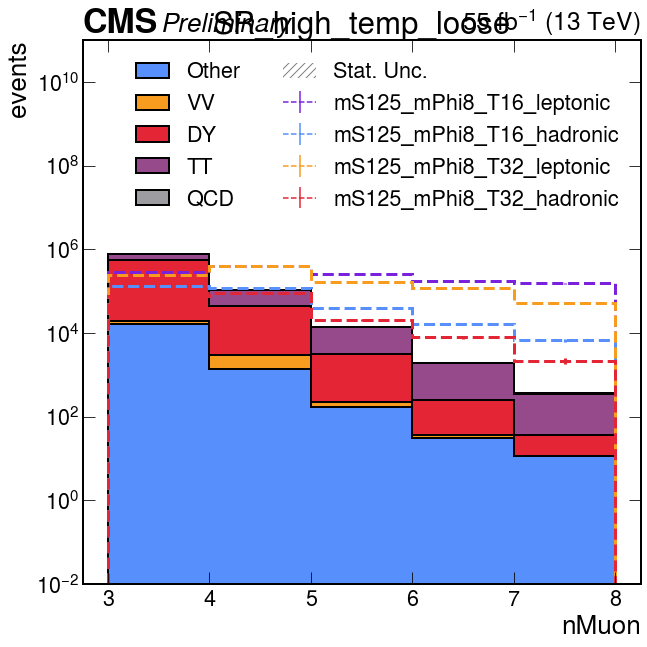

In [67]:
regions = [
    'CR_prompt',
    'CR_light',
    'CR_cb',
    'SR_high_temp_tight',
    'SR_high_temp_loose'
]
mc_processes = [
    'Other_2018',
    'VV_2018',
    'DY_2018',
    'TT_powheg_2018',
    'QCD_Pt_MuEnriched_2018'
]
mc_labels = [
    'Other',
    'VV',
    'DY',
    'TT',
    'QCD'
]

signal_processes = [
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
]
signal_labels = [
    'mS125_mPhi8_T16_leptonic',
    'mS125_mPhi8_T16_hadronic',
    'mS125_mPhi8_T32_leptonic',
    'mS125_mPhi8_T32_hadronic',    
]

for region in regions:
    hists_mc = []
    hist_bkg_total = None

    for process in mc_processes:
        h_mc = plots[process][region]
        hists_mc.append(h_mc)
        if hist_bkg_total is None:
            hist_bkg_total = h_mc.copy()
        else:
            hist_bkg_total += h_mc.copy()

    hists_signal = []
    for process in signal_processes:
        h_signal = plots[process][region]
        hists_signal.append(h_signal)

    fig, ax = plt.subplots(figsize=(10,10))

    hep.histplot(
        hists_mc, 
        stack=True, 
        label=mc_labels,        
        histtype="fill",
        ec="black",
        lw=2,
        ax=ax,
    )

    x_hatch = np.vstack(
        (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
    ).reshape((-1,), order="F")
    y_hatch1 = np.vstack((hist_bkg_total.values(), hist_bkg_total.values())).reshape(
        (-1,), order="F"
    )
    y_hatch1_unc = np.vstack(
        (np.sqrt(hist_bkg_total.variances()), np.sqrt(hist_bkg_total.variances()))
    ).reshape((-1,), order="F")
    ax.fill_between(
        x=x_hatch,
        y1=y_hatch1 - y_hatch1_unc,
        y2=y_hatch1 + y_hatch1_unc,
        label="Stat. Unc.",
        step="pre",
        facecolor="none",
        edgecolor=(0, 0, 0, 0.5),
        linewidth=0,
        hatch="///",
        zorder=2,
    )

    hep.histplot(
        hists_signal,
        label=signal_labels,
        lw=3,
        ls="--",
        ax=ax,
    )

    hep.cms.label(llabel="Preliminary", data=True, lumi=55, ax=ax)
    plt.title(region)
    plt.gca().xaxis.set_minor_locator(plt.NullLocator())
    plt.ylim(1e-2, 1e11)
    plt.yscale('log')
    plt.legend(ncol=2)
    plt.xlabel("nMuon")
    plt.ylabel("events")
    plt.show()

In [11]:
31570.26232383 / 28**3

1.4381497049849672

In [112]:
np.sqrt(60827649.31823292) / 28**3

0.35528463235451935

In [18]:
print(0.1484 + 0.1375)
print(np.sqrt(0.2394**2 + 0.0366**2))

0.28590000000000004

0.24218158476647228

In [106]:
B

27.975692090018423

In [91]:
var_B

3.8488882765894243

WeightedSum(value=0.337482, variance=0.00448377)

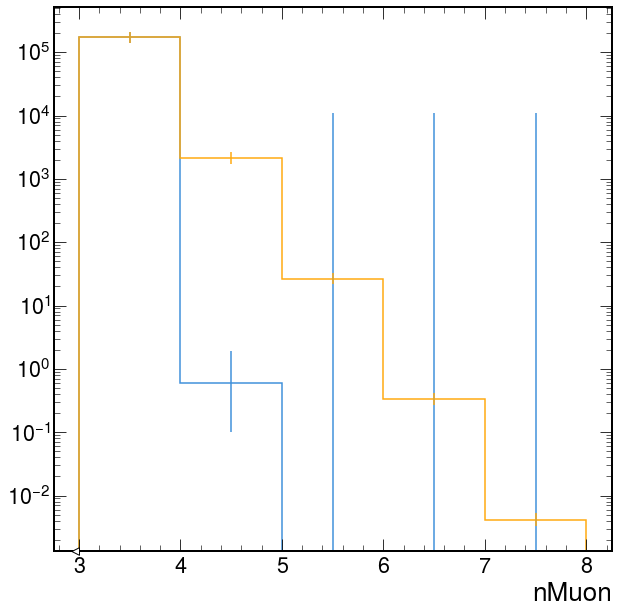

In [95]:
B_custom = 80
plots['QCD_Pt_MuEnriched_2018'][
    'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon'
][0.007j, 0.8j, 0.1j, 30j, :].plot()
pred_new(
    plots['QCD_Pt_MuEnriched_2018'][
        'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon'
    ][0.007j, 0.8j, 0.1j, 30j, :], B_custom, var_B
).plot()
plt.yscale('log')

print(
    pred_new(
        plots['QCD_Pt_MuEnriched_2018'][
            'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon'
        ][0.007j, 0.8j, 0.1j, 30j, :], B_custom, var_B
    )[6j::sum]
)

## Plot overlay of bkgs for nMuon distribution

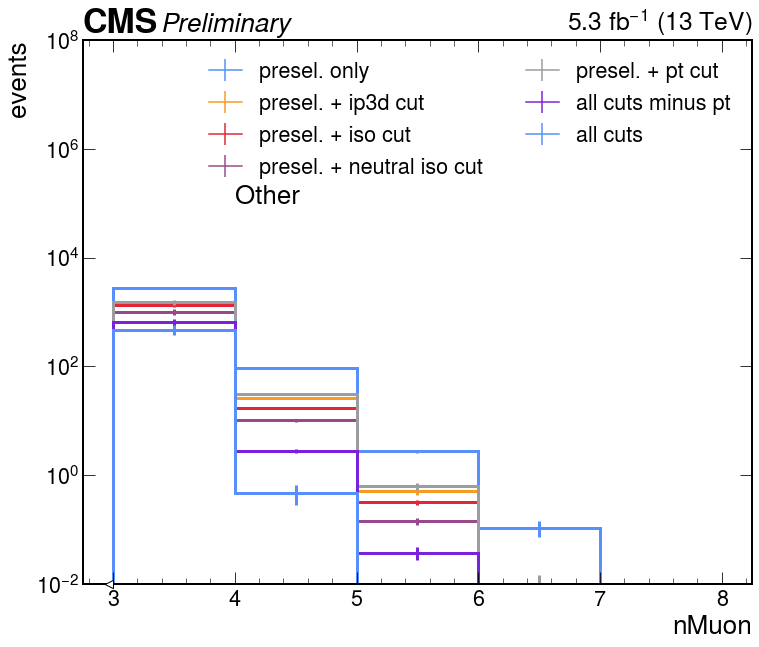

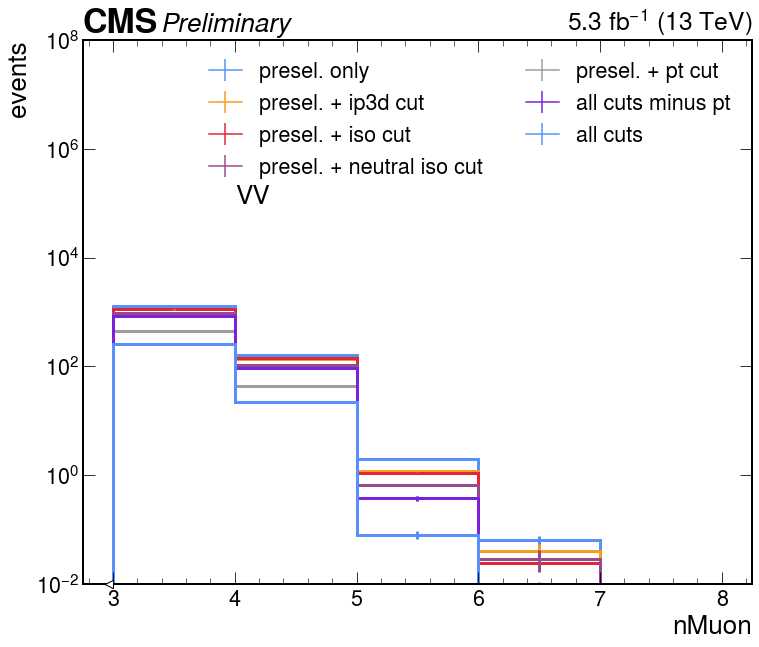

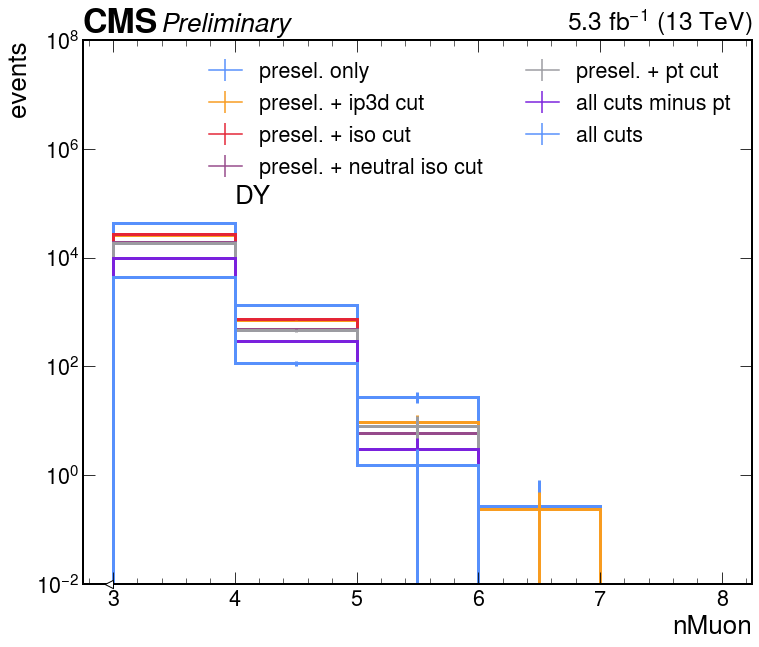

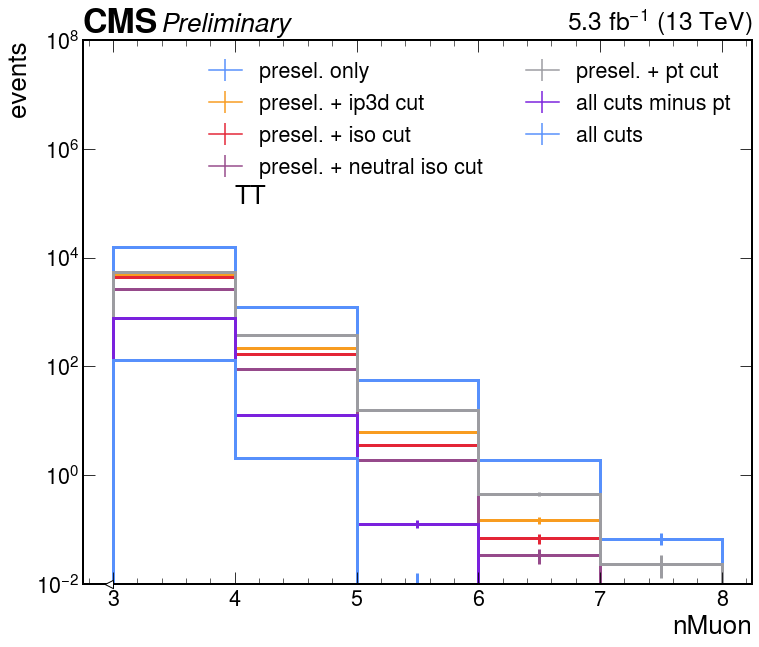

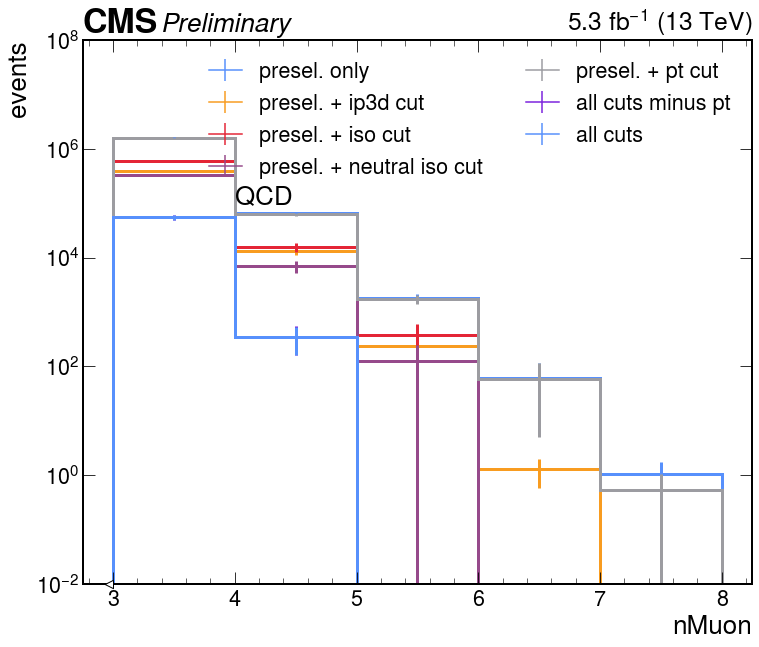

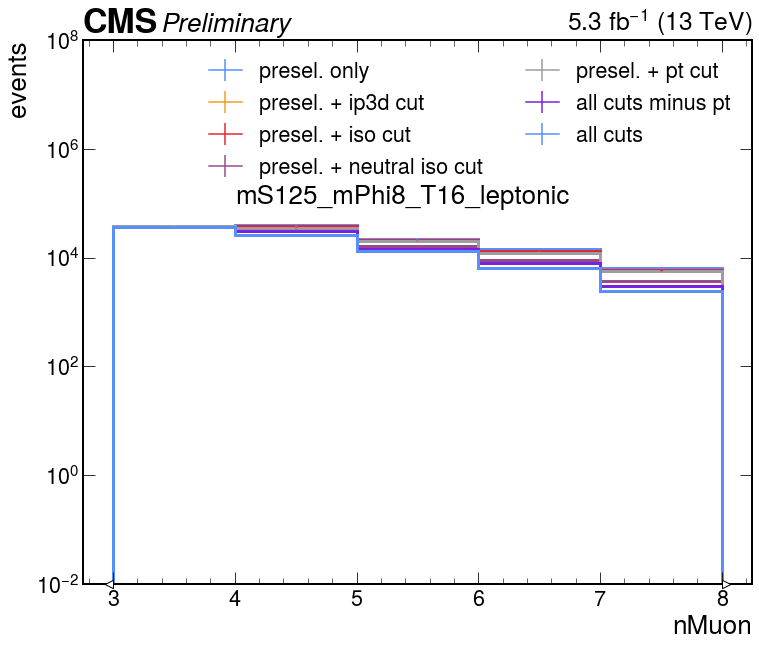

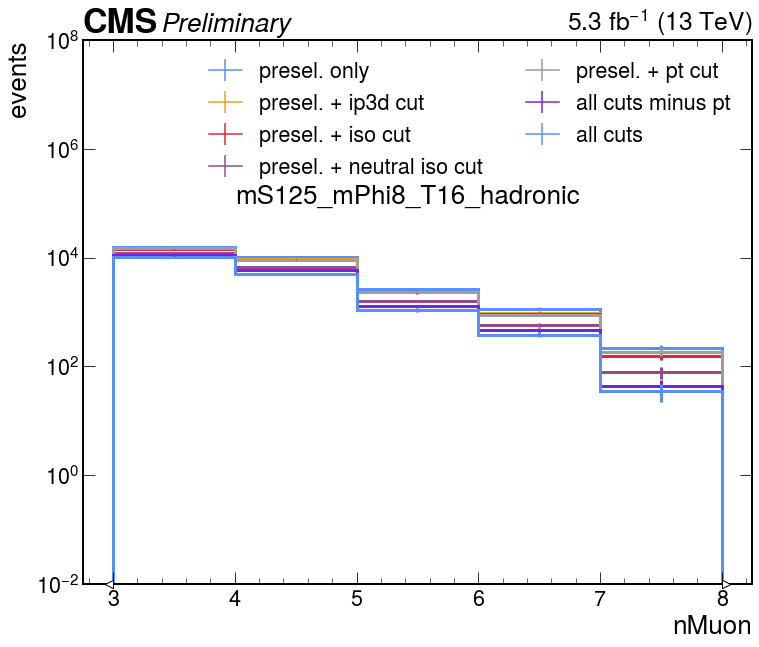

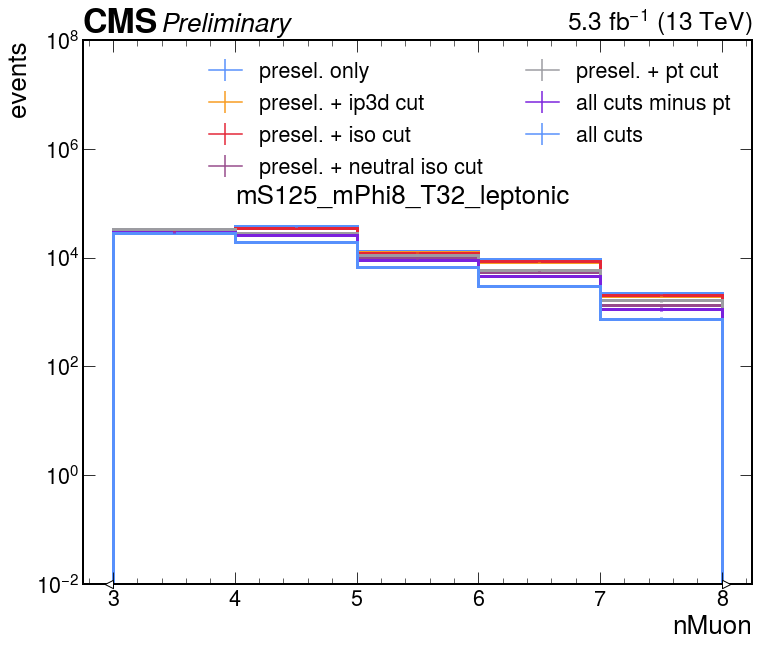

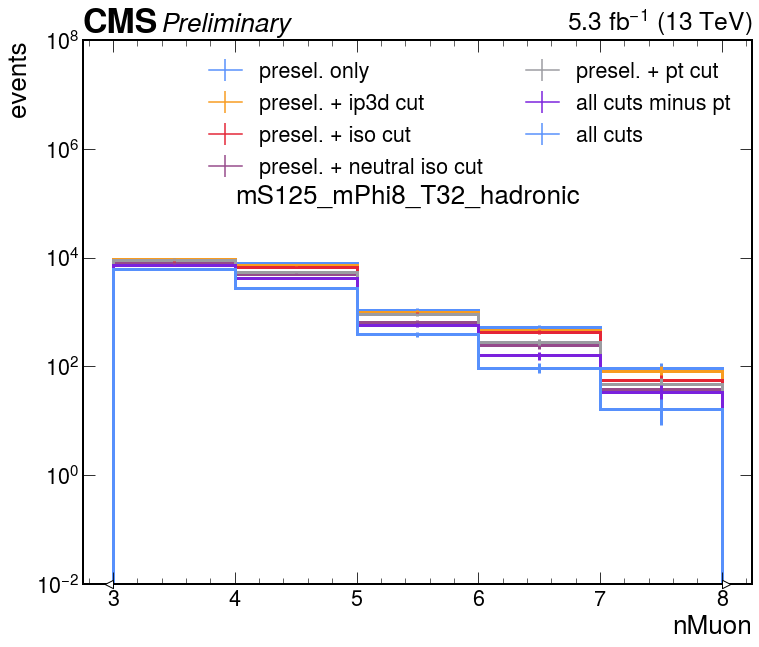

In [106]:
processes = [
    'Other_2018',
    'VV_2018',
    'DY_2018',
    'TT_powheg_2018',
    'QCD_Pt_MuEnriched_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
]
proc_labels = [
    'Other',
    'VV',
    'DY',
    'TT',
    'QCD',
    'mS125_mPhi8_T16_leptonic',
    'mS125_mPhi8_T16_hadronic',
    'mS125_mPhi8_T32_leptonic',
    'mS125_mPhi8_T32_hadronic',    
]

for process, proc_label in zip(processes, proc_labels):
    slices = [
        (0, 0, 0, 0, slice(None)),
        (1, 0, 0, 0, slice(None)),
        (0, 1, 0, 0, slice(None)),
        (0, 0, 1, 0, slice(None)),
        (0, 0, 0, 1, slice(None)),
        (1, 1, 1, 0, slice(None)),
        (1, 1, 1, 1, slice(None)),
    ]
    labels = [
        'presel. only',
        'presel. + ip3d cut',
        'presel. + iso cut',
        'presel. + neutral iso cut',
        'presel. + pt cut',
        'all cuts minus pt',
        'all cuts',
    ]

    hist_name = 'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon'

    hists_mc = []
    for slc, label in zip(slices, labels):
        h_mc = plots[process][hist_name][slc]
        hists_mc.append(h_mc)
#         print(label)
#         print(h_mc.values())
#         print(np.sqrt(h_mc.variances()))


    fig, ax = plt.subplots(figsize=(12,10))

    hep.histplot(
        hists_mc,
        yerr=[np.sqrt(h.variances()) for h in hists_mc],
        label=labels,        
        lw=3,
        ax=ax,
    )

    hep.cms.label(llabel="Preliminary", data=True, lumi=5.3, ax=ax)
    plt.text(4, 1e5, proc_label)
    plt.ylim(1e-2, 1e8)
    plt.yscale('log')
    plt.legend(ncol=2)
    plt.xlabel("nMuon")
    plt.ylabel("events")
    plt.show()

In [ ]:
data = 'DoubleMuon+Run2018A-UL2018_MiniAODv2-v1+MINIAOD_histograms_2018'
mc_process = 'DY_2018'
mc_labels = [
    'DY',
]

signal_processes = [
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
]
signal_labels = [
    'mS125_mPhi8_T16_leptonic',
    'mS125_mPhi8_T16_hadronic',
    'mS125_mPhi8_T32_leptonic',
    'mS125_mPhi8_T32_hadronic',    
]

hist_name = 'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_nMuon'
slc = (0, 0, 0, slice(None))

hists_mc = []

for process in mc_processes:
    h_mc = plots[process][hist_name][slc]
    hists_mc.append(h_mc)
    print(process, h_mc.values())

fig, ax = plt.subplots(figsize=(12,10))

hep.histplot(
    hists_mc,
    yerr=[np.sqrt(h.variances()) for h in hists_mc],
    label=mc_labels,        
    lw=3,
    ax=ax,
)
    
hep.cms.label(llabel="Preliminary", data=True, lumi=5.3, ax=ax)
plt.ylim(1e-2, 1e6)
plt.yscale('log')
plt.legend(ncol=2)
plt.xlabel("nMuon")
plt.ylabel("events")
plt.show()

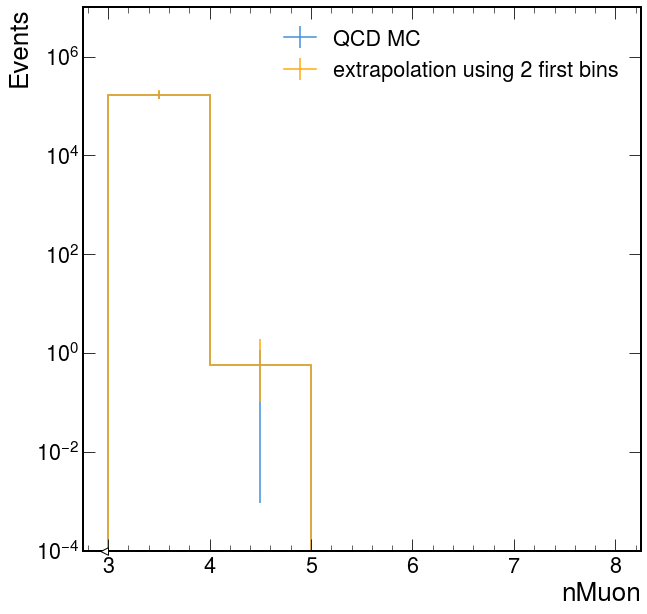

0.0000 ± 0.0000

[ 1.  1. inf inf inf]

[0.26434339 1.41194756        nan        nan        nan]

In [77]:
def pred(h_in, offset=0):
    # Use bins offset, offset+1 to guess the function. Defaults to 0, 1.
    f0 = h_in.values()[offset]
    f1 = h_in.values()[1+offset]
    var_f0 = h_in.variances()[offset]
    var_f1 = h_in.variances()[1+offset]
    values = [f1 * (f1 / f0)**(n - 1) for n in range(len(h_in.values()))]
    variances = [
        (
            ((n - 1) * (f1 / f0)**n)**2 * var_f0 + (n * (f1 / f0)**(n - 1))**2 * var_f1
        ) for n in range(len(h_in.values()))
    ]
    h_out = h_in.copy().reset()
    for i in range(len(h_in.values())):
        h_out[i] = (values[i], variances[i])
    return h_out

h = plots['QCD_Pt_MuEnriched_2018'][
    'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon'
][0.007j, 0.8j, 0.1j, 30j, :]

h.plot(yerr=np.sqrt(h.variances()), label='QCD MC')
pred(h).plot(label='extrapolation using 2 first bins')
plt.ylabel('Events')
plt.yscale('log')
plt.ylim(1e-4, 1e7)
plt.legend()
plt.show()

print(f"{pred(h)[6j::sum].value:.4f} ± {np.sqrt(pred(h)[6j::sum].variance):.4f}")

print(pred(h).values() / h.values())
print(np.sqrt(pred(h).variances() / (h.values()**2) + pred(h).values()**2 * h.variances() / (h.values()**4)))

WeightedSum(value=45253, variance=791947)

WeightedSum(value=1165.19, variance=11202.7)

WeightedSum(value=15.6362, variance=252.884)

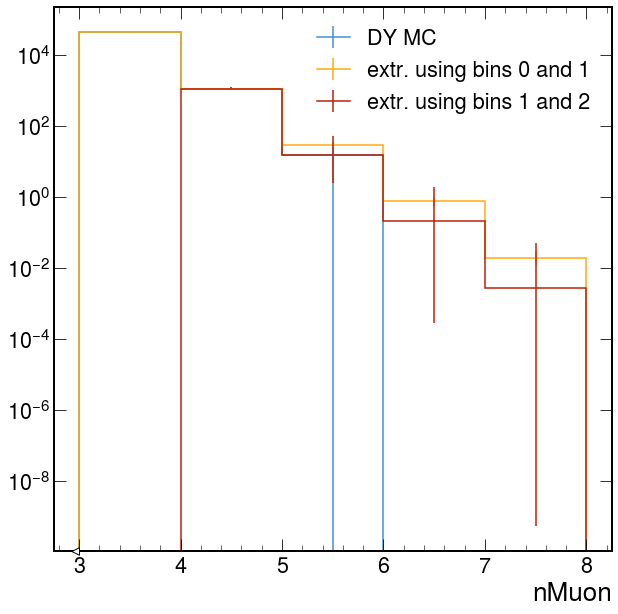

0.7924 ± 0.2128

0.2126 ± 0.4273

In [39]:
h = plots['DY_2018']['ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon'][1, 1, 1, 1, :]

print(h[0])
print(h[1])
print(h[2])

h.plot(yerr=np.sqrt(h.variances()), label='DY MC')
pred(h).plot(label='extr. using bins 0 and 1')
pred(h[1:]).plot(label='extr. using bins 1 and 2')
plt.yscale('log')
plt.legend()
plt.show()

print(f"{pred(h)[6j::sum].value:.4f} ± {np.sqrt(pred(h)[6j::sum].variance):.4f}")
print(f"{pred(h[1:])[6j::sum].value:.4f} ± {np.sqrt(pred(h[1:])[6j::sum].variance):.4f}")

In [20]:
print(0.0009 + 0.0199 + 0.014)
print(np.sqrt(0.0021**2 + 0.0073**2 + 0.0032**2))

0.034800000000000005

0.00824257241399795

In [40]:
print(0.0142 + 0.7924 + 0.1479)


print(np.sqrt(0.0032**2 + 0.2128**2 + 0.2406**2))

0.9545

0.32122023597525734

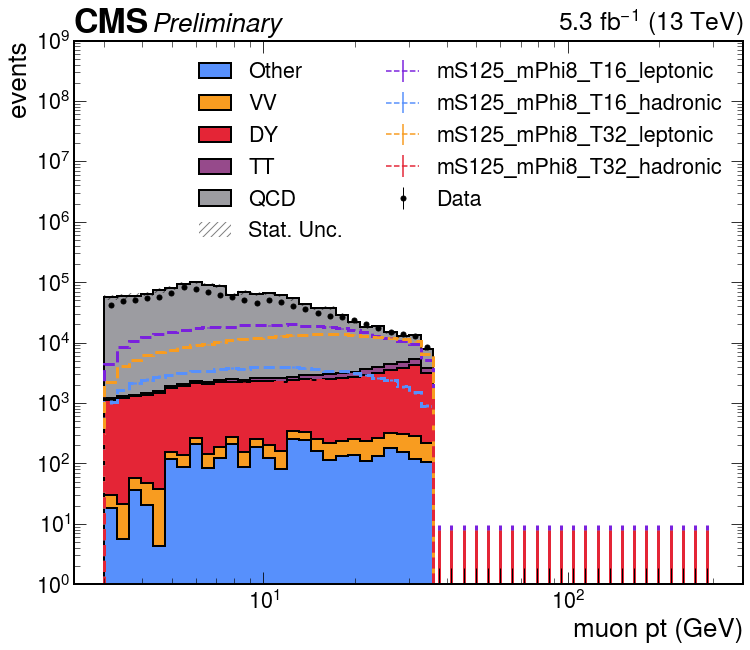

In [16]:
data = 'DoubleMuon+Run2018A-UL2018_MiniAODv2-v1+MINIAOD_histograms_2018'
mc_processes = [
    'Other_2018',
    'VV_2018',
    'DY_2018',
    'TT_powheg_2018',
    'QCD_Pt_MuEnriched_2018'
]
mc_labels = [
    'Other',
    'VV',
    'DY',
    'TT',
    'QCD'
]

signal_processes = [
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
]
signal_labels = [
    'mS125_mPhi8_T16_leptonic',
    'mS125_mPhi8_T16_hadronic',
    'mS125_mPhi8_T32_leptonic',
    'mS125_mPhi8_T32_hadronic',    
]


hist_name = 'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_muon_pt'
slc = (1, 1, 1, 1, slice(None, None, 2j))

hists_mc = []
hist_bkg_total = None

for process in mc_processes:
    h_mc = plots[process][hist_name][slc]
    hists_mc.append(h_mc)
    if hist_bkg_total is None:
        hist_bkg_total = h_mc.copy()
    else:
        hist_bkg_total += h_mc.copy()

h_data = plots[data][hist_name][slc]

hists_signal = []
for process in signal_processes:
    h_signal = plots[process][hist_name][slc]
    hists_signal.append(h_signal)

fig, ax = plt.subplots(figsize=(12,10))

hep.histplot(
    hists_mc, 
    stack=True, 
    label=mc_labels,        
    histtype="fill",
    ec="black",
    lw=2,
    ax=ax,
)

x_hatch = np.vstack(
    (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
).reshape((-1,), order="F")
y_hatch1 = np.vstack((hist_bkg_total.values(), hist_bkg_total.values())).reshape(
    (-1,), order="F"
)
y_hatch1_unc = np.vstack(
    (np.sqrt(hist_bkg_total.variances()), np.sqrt(hist_bkg_total.variances()))
).reshape((-1,), order="F")
ax.fill_between(
    x=x_hatch,
    y1=y_hatch1 - y_hatch1_unc,
    y2=y_hatch1 + y_hatch1_unc,
    label="Stat. Unc.",
    step="pre",
    facecolor="none",
    edgecolor=(0, 0, 0, 0.5),
    linewidth=0,
    hatch="///",
    zorder=2,
)

hep.histplot(
    hists_signal,
    label=signal_labels,
    lw=3,
    ls="--",
    ax=ax,
)

hep.histplot(
    h_data,
    label=["Data"],
    histtype="errorbar",
    mec="black",
    mfc="black",
    ecolor="black",
    ax=ax
)
    
hep.cms.label(llabel="Preliminary", data=True, lumi=5.3, ax=ax)
plt.ylim(1e0, 1e9)
plt.xscale('log')
plt.yscale('log')
plt.legend(ncol=2)
plt.xlabel("muon pt (GeV)")
plt.ylabel("events")
plt.show()

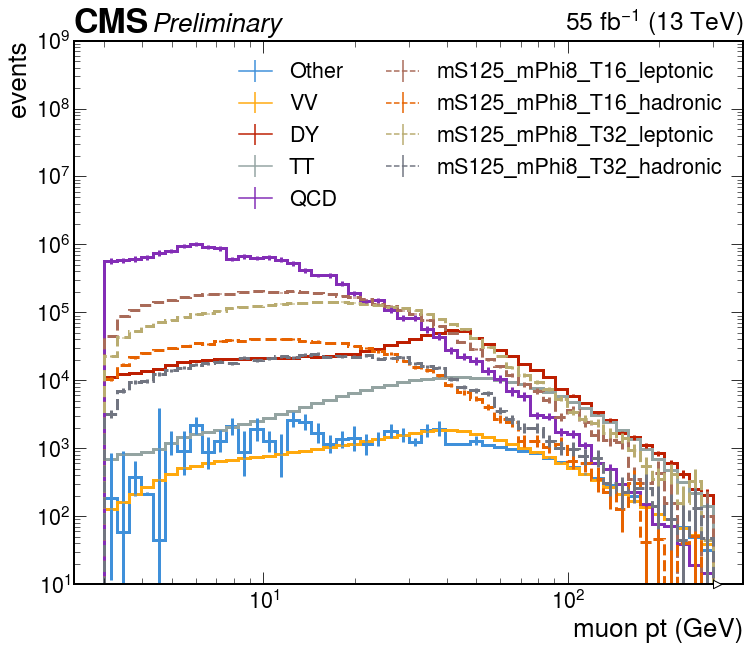

In [21]:
mc_processes = [
    'Other_2018',
    'VV_2018',
    'DY_2018',
    'TT_powheg_2018',
    'QCD_Pt_MuEnriched_2018'
]
mc_labels = [
    'Other',
    'VV',
    'DY',
    'TT',
    'QCD'
]

signal_processes = [
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
]
signal_labels = [
    'mS125_mPhi8_T16_leptonic',
    'mS125_mPhi8_T16_hadronic',
    'mS125_mPhi8_T32_leptonic',
    'mS125_mPhi8_T32_hadronic',    
]


hist_name = 'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_muon_pt'
slc = (1, 1, 1, 0, slice(None, None, 2j))

hists_mc = []
hist_bkg_total = None

for process in mc_processes:
    h_mc = plots[process][hist_name][slc]
    hists_mc.append(h_mc)

hists_signal = []
for process in signal_processes:
    h_signal = plots[process][hist_name][slc]
    hists_signal.append(h_signal)

fig, ax = plt.subplots(figsize=(12,10))

hep.histplot(
    hists_mc, 
    label=mc_labels,        
    lw=3,
    ax=ax,
)

hep.histplot(
    hists_signal,
    label=signal_labels,
    lw=3,
    ls="--",
    ax=ax,
)
    
#hep.cms.label(llabel="Preliminary", data=True, lumi=5.3, ax=ax)
hep.cms.label(llabel="Preliminary", data=True, lumi=55, ax=ax)
plt.ylim(1e1, 1e9)
plt.xscale('log')
plt.yscale('log')
plt.legend(ncol=2)
plt.xlabel("muon pt (GeV)")
plt.ylabel("events")
plt.show()

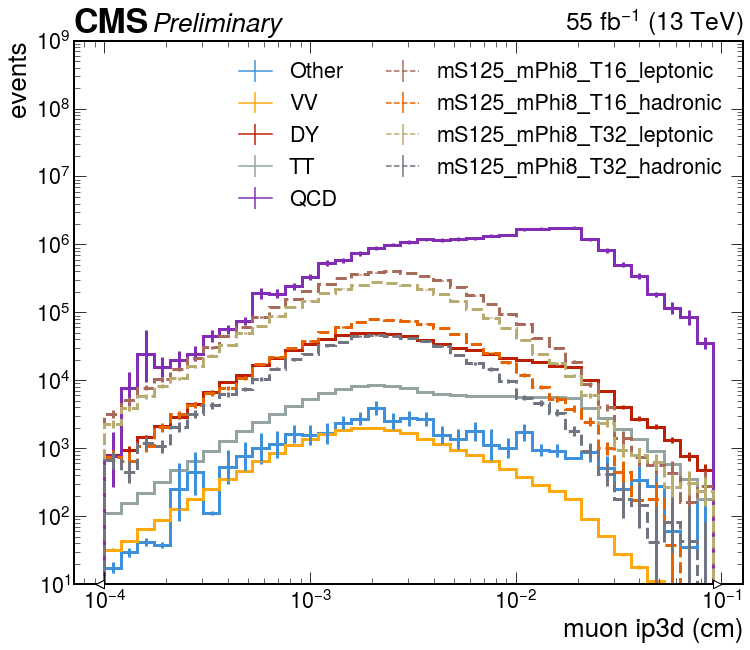

In [32]:
mc_processes = [
    'Other_2018',
    'VV_2018',
    'DY_2018',
    'TT_powheg_2018',
    'QCD_Pt_MuEnriched_2018'
]
mc_labels = [
    'Other',
    'VV',
    'DY',
    'TT',
    'QCD'
]

signal_processes = [
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
]
signal_labels = [
    'mS125_mPhi8_T16_leptonic',
    'mS125_mPhi8_T16_hadronic',
    'mS125_mPhi8_T32_leptonic',
    'mS125_mPhi8_T32_hadronic',    
]


hist_name = 'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_muon_ip3d'
slc = (0, 1, 1, 1, slice(None, 1e-1j, 2j))

hists_mc = []
hist_bkg_total = None

for process in mc_processes:
    h_mc = plots[process][hist_name][slc]
    hists_mc.append(h_mc)

hists_signal = []
for process in signal_processes:
    h_signal = plots[process][hist_name][slc]
    hists_signal.append(h_signal)

fig, ax = plt.subplots(figsize=(12,10))

hep.histplot(
    hists_mc, 
    label=mc_labels,        
    lw=3,
    ax=ax,
)

hep.histplot(
    hists_signal,
    label=signal_labels,
    lw=3,
    ls="--",
    ax=ax,
)

hep.cms.label(llabel="Preliminary", data=True, lumi=55, ax=ax)
# hep.cms.label(llabel="Preliminary", data=True, lumi=5.3, ax=ax)
plt.ylim(1e1, 1e9)
plt.xscale('log')
plt.yscale('log')
plt.legend(ncol=2)
plt.xlabel("muon ip3d (cm)")
plt.ylabel("events")
plt.show()

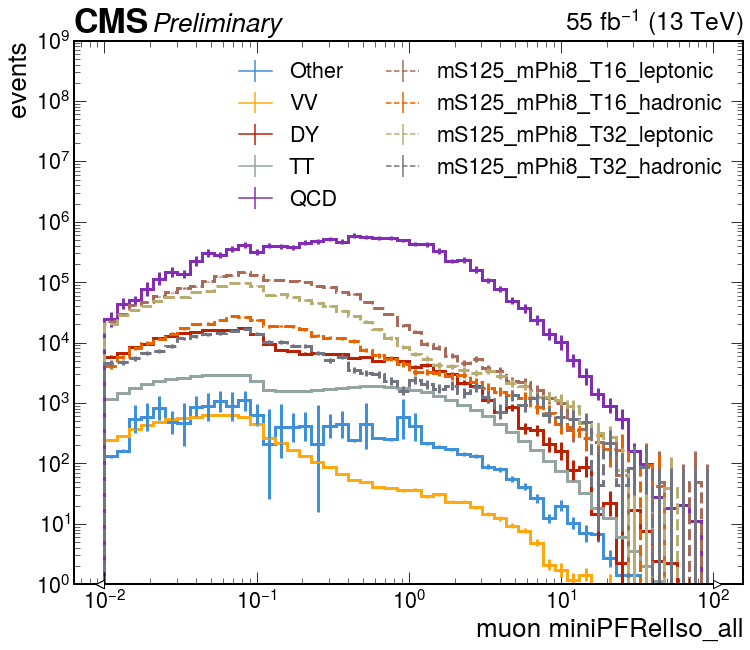

In [30]:
mc_processes = [
    'Other_2018',
    'VV_2018',
    'DY_2018',
    'TT_powheg_2018',
    'QCD_Pt_MuEnriched_2018'
]
mc_labels = [
    'Other',
    'VV',
    'DY',
    'TT',
    'QCD'
]

signal_processes = [
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
]
signal_labels = [
    'mS125_mPhi8_T16_leptonic',
    'mS125_mPhi8_T16_hadronic',
    'mS125_mPhi8_T32_leptonic',
    'mS125_mPhi8_T32_hadronic',    
]


hist_name = 'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_muon_miniPFRelIso_all'
slc = (1, 0, 1, 1, slice(None, None, 2j))

hists_mc = []
hist_bkg_total = None

for process in mc_processes:
    h_mc = plots[process][hist_name][slc]
    hists_mc.append(h_mc)

hists_signal = []
for process in signal_processes:
    h_signal = plots[process][hist_name][slc]
    hists_signal.append(h_signal)

fig, ax = plt.subplots(figsize=(12,10))

hep.histplot(
    hists_mc, 
    label=mc_labels,        
    lw=3,
    ax=ax,
)

hep.histplot(
    hists_signal,
    label=signal_labels,
    lw=3,
    ls="--",
    ax=ax,
)
    
#hep.cms.label(llabel="Preliminary", data=True, lumi=5.3, ax=ax)
hep.cms.label(llabel="Preliminary", data=True, lumi=55, ax=ax)
plt.ylim(1e0, 1e9)
plt.xscale('log')
plt.yscale('log')
plt.legend(ncol=2)
plt.xlabel("muon miniPFRelIso_all")
plt.ylabel("events")
plt.show()

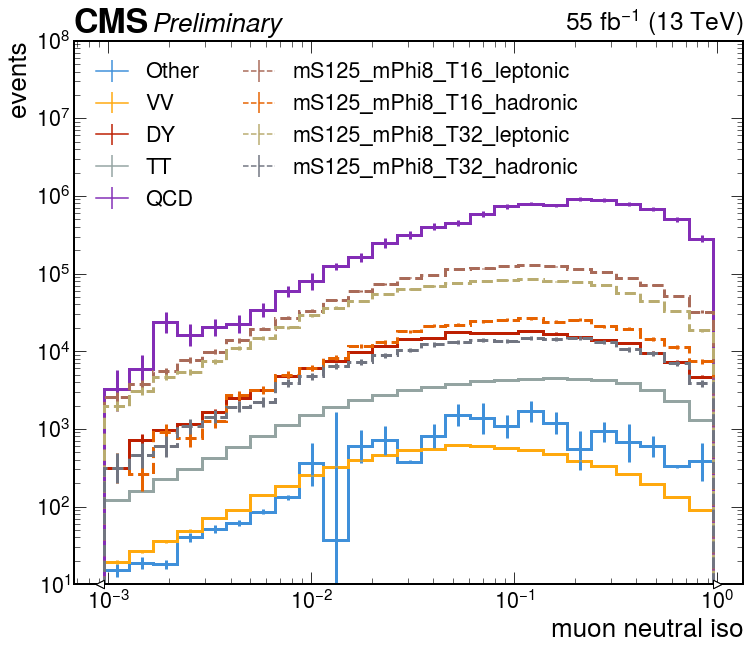

In [29]:
mc_processes = [
    'Other_2018',
    'VV_2018',
    'DY_2018',
    'TT_powheg_2018',
    'QCD_Pt_MuEnriched_2018'
]
mc_labels = [
    'Other',
    'VV',
    'DY',
    'TT',
    'QCD'
]

signal_processes = [
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
]
signal_labels = [
    'mS125_mPhi8_T16_leptonic',
    'mS125_mPhi8_T16_hadronic',
    'mS125_mPhi8_T32_leptonic',
    'mS125_mPhi8_T32_hadronic',    
]


hist_name = 'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_muon_neutral_iso'
slc = (1, 1, 0, 1, slice(1e-3j, 1j, 2j))

hists_mc = []
hist_bkg_total = None

for process in mc_processes:
    h_mc = plots[process][hist_name][slc]
    hists_mc.append(h_mc)

hists_signal = []
for process in signal_processes:
    h_signal = plots[process][hist_name][slc]
    hists_signal.append(h_signal)

fig, ax = plt.subplots(figsize=(12,10))

hep.histplot(
    hists_mc, 
    label=mc_labels,        
    lw=3,
    ax=ax,
)

hep.histplot(
    hists_signal,
    label=signal_labels,
    lw=3,
    ls="--",
    ax=ax,
)
    
#hep.cms.label(llabel="Preliminary", data=True, lumi=5.3, ax=ax)
hep.cms.label(llabel="Preliminary", data=True, lumi=55, ax=ax)
plt.ylim(1e1, 1e8)
plt.xscale('log')
plt.yscale('log')
plt.legend(ncol=2)
plt.xlabel("muon neutral iso")
plt.ylabel("events")
plt.show()

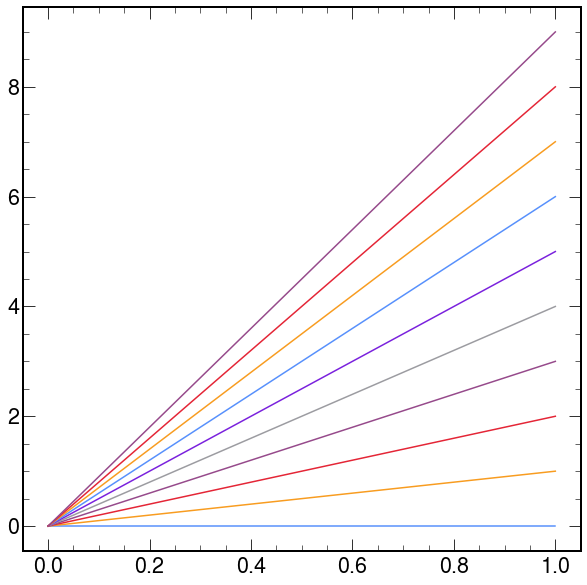

In [23]:
for i in range(10):
    plt.plot([0,1], [0,i])
plt.show()

In [75]:
from cycler import cycler

cmap_petroff_6 = ["#5790fc", "#f89c20", "#e42536", "#964a8b", "#9c9ca1", "#7a21dd"]
cmap_petroff_10 = [
    "#3f90da",
    "#ffa90e",
    "#bd1f01",
    "#94a4a2",
    "#832db6",
    "#a96b59",
    "#e76300",
    "#b9ac70",
    "#717581",
    "#92dadd",
]

CMS = {
    "axes.prop_cycle": cycler("color", cmap_petroff_10)
}
plt.style.use(CMS)

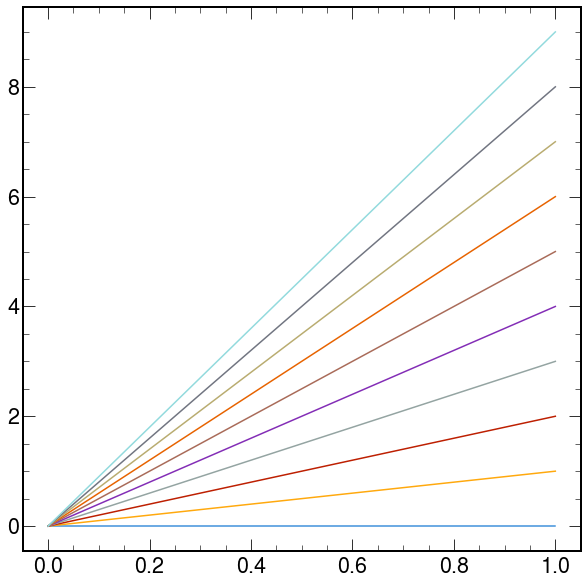

In [25]:
for i in range(10):
    plt.plot([0,1], [0,i])
plt.show()

In [33]:
import ROOT

In [41]:
ROOT.RooStats.AsimovSignificance(1e5, 1, 1)

372.29985605662216

In [42]:
ROOT.RooStats.AsimovSignificance(1e5, 0.1, 0.1)

692.4988800685229

In [61]:
ROOT.RooStats.AsimovSignificance(1, 0.1, )

1.8097982208402172

In [130]:
print(
    [ROOT.RooStats.AsimovSignificance(1e0, i, 0.45 * i) 
    / ROOT.RooStats.AsimovSignificance(1e1, i, 0.45 * i) for i in [1e-4, 1e-3, 1e-2, 1e-1, 1]]
)

[0.2869140563317708, 0.27751377679296346, 0.2603140306067026, 0.22626200883310232, 0.16970594411087875]

In [115]:
1/6.661e-3

150.12760846719712

In [120]:
0.0076*1.3 / 0.0222

0.445045045045045

## Try Chris' method

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f20d7d28250>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

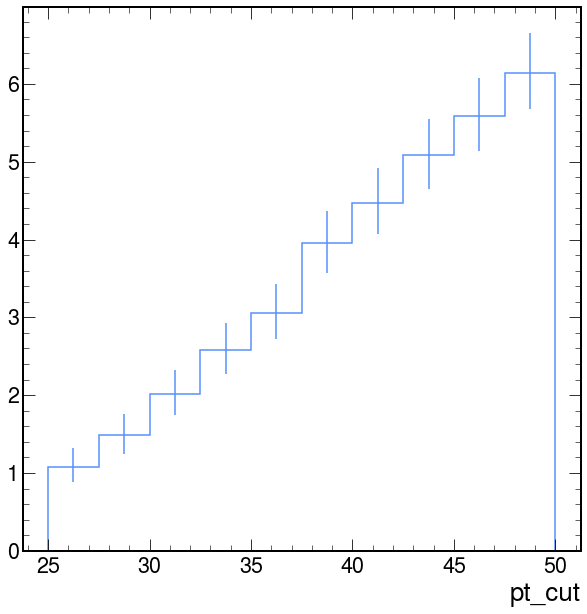

In [66]:
plots['TT_powheg_2018'][
    'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon'
][0.09j, 1j, 0.9j, :, 5j::sum].plot()

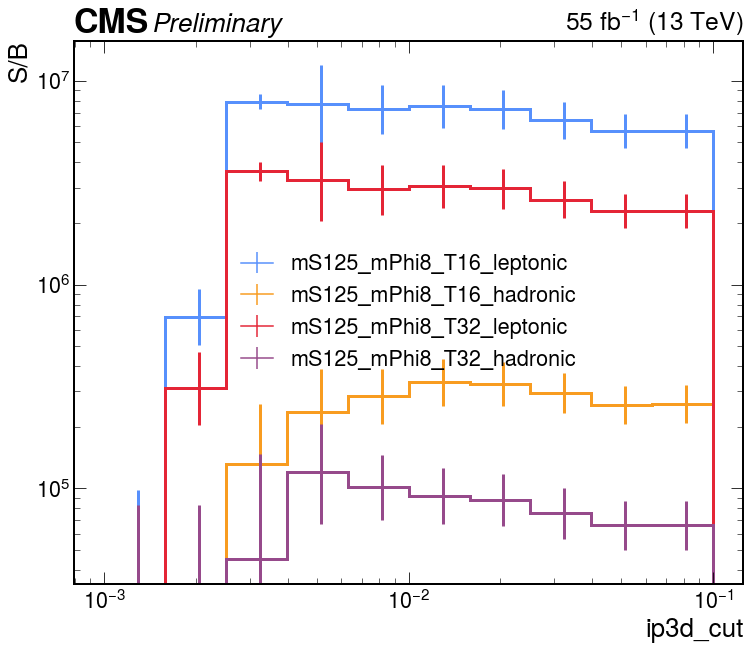

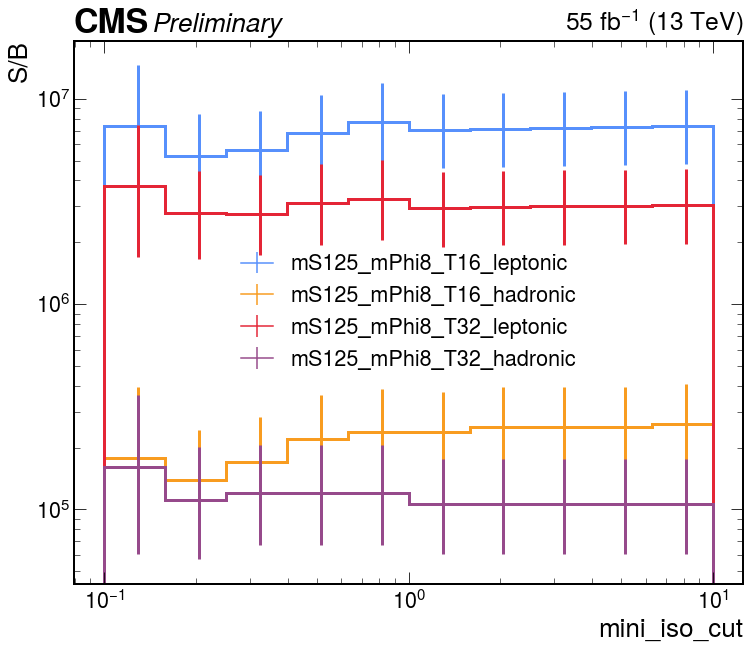

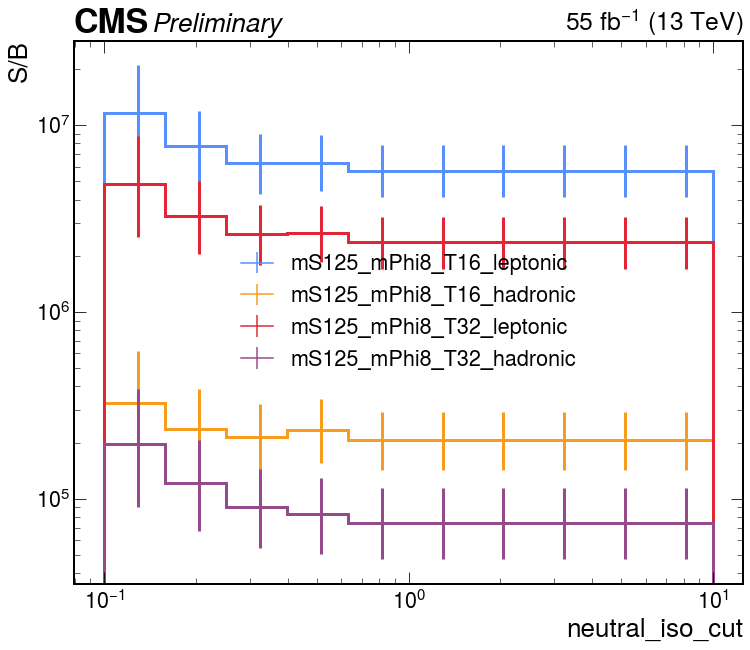

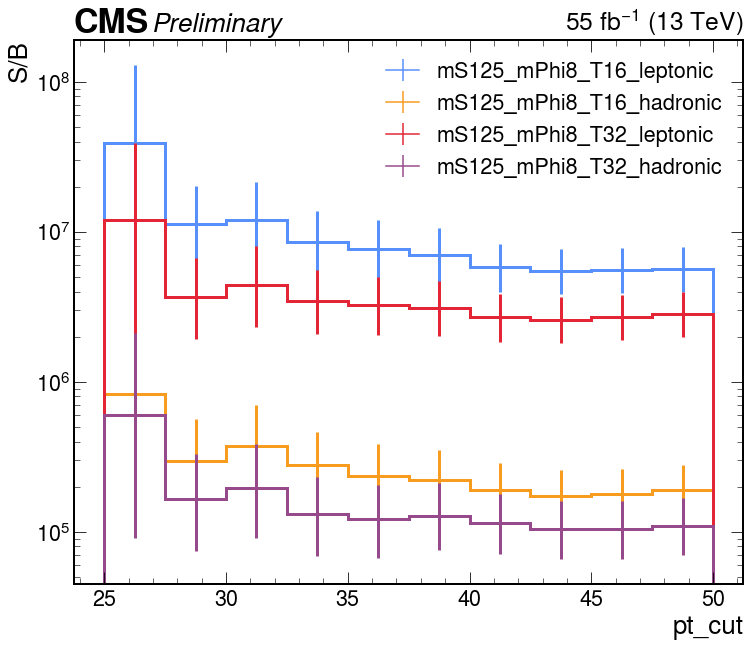

In [90]:
mc_processes = [
    'Other_2018',
    'VV_2018',
    'DY_2018',
    'TT_powheg_2018',
    'QCD_Pt_MuEnriched_2018'
]
mc_labels = [
    'Other',
    'VV',
    'DY',
    'TT',
    'QCD'
]

signal_processes = [
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
]
signal_labels = [
    'mS125_mPhi8_T16_leptonic',
    'mS125_mPhi8_T16_hadronic',
    'mS125_mPhi8_T32_leptonic',
    'mS125_mPhi8_T32_hadronic',    
]

histname = 'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon'

# Begin using the starting point: 
#default_cut = (0.1j*0.99, 10j*0.99, 10j*0.99, 50j*0.99)
default_cut = (0.006j, 0.5j, 0.2j, 30j)

cuts = [
    (slice(None), default_cut[1], default_cut[2], default_cut[3], slice(6j, None, sum)),
    (default_cut[0], slice(None), default_cut[2], default_cut[3], slice(6j, None, sum)),
    (default_cut[0], default_cut[1], slice(None), default_cut[3], slice(6j, None, sum)),
    (default_cut[0], default_cut[1], default_cut[2], slice(None), slice(6j, None, sum)),
]

for j, slc in enumerate(cuts):
    hist_bkg_total = None

    for process in mc_processes:
        h_mc = plots[process][histname][slc]
        # Here I could feed h_mc to the prediction function
#         if 
#         if "QCD" in process:
#             h_mc = pred(h_mc, offset=0)
#         elif "DY" in process:
#             h_mc = pred(h_mc, offset=1)
        if hist_bkg_total is None:
            hist_bkg_total = h_mc.copy()
        else:
            hist_bkg_total += h_mc.copy()

    hists_s_over_b = []
    for process in signal_processes:
        h_s = plots[process][histname][slc]
        h_s_over_b = h_s.copy()
        for i in range(len(h_s_over_b.values())):
            tot_bkg = hist_bkg_total[i].value
            if tot_bkg == 0:
                tot_bkg = 1e-3

            h_s_over_b[i] = (
                h_s[i].value / tot_bkg,
                h_s[i].variance / tot_bkg**2
                + h_s[i].value**2 * hist_bkg_total[i].variance / tot_bkg**4
            )
        hists_s_over_b.append(h_s_over_b)

    fig, ax = plt.subplots(figsize=(12,10))

    hep.histplot(
        hists_s_over_b, 
        label=signal_labels,        
        lw=3,
        ax=ax,
    )

    hep.cms.label(llabel="Preliminary", data=True, lumi=55, ax=ax)
    #plt.ylim(1e-2, 2e0)
    if hist_bkg_total.axes[0].name != "pt_cut":
        ax.set_xscale('log')
    ax.set_yscale('log')
    plt.legend()
    plt.ylabel("S/B")
    plt.show()

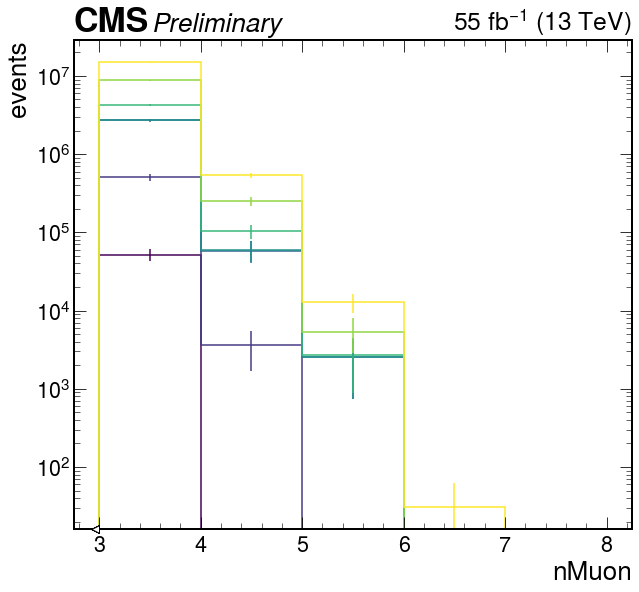

In [11]:
process = 'QCD_Pt_MuEnriched_2018'
# process = 'DY_2018'

N = 7
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.viridis(np.linspace(0,1,N)))

histogram = plots[process]['ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon']

cuts = [
    (0.006j, 1j, 0.2j, 35j, slice(None)),
    (0.01j, 1j, 0.2j, 35j, slice(None)),
    (0.02j, 2j, 0.5j, 35j, slice(None)),
    (0.02j, 2j, 0.5j, 49j, slice(None)),
    (0.02j, 5j, 1j, 49j, slice(None)),
    (0.05j, 5j, 1j, 49j, slice(None)),
    (0.09j, 9j, 9j, 49j, slice(None))
]

fig, ax = plt.subplots(figsize=(10,9))

for cut in cuts:
    histogram[cut].plot(
        yerr=np.sqrt(histogram[cut].variances())
    )

hep.cms.label(llabel="Preliminary", data=True, lumi=55)
plt.yscale('log')
plt.ylabel('events')
plt.show()

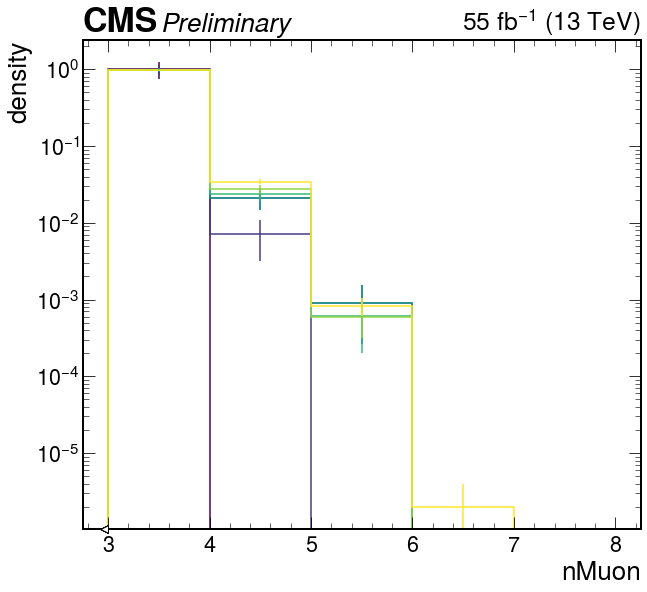

In [18]:
process = 'QCD_Pt_MuEnriched_2018'
# process = 'DY_2018'

N = 7
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.viridis(np.linspace(0,1,N)))

histogram = plots[process]['ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon']

cuts = [
    (0.006j, 1j, 0.2j, 35j, slice(None)),
    (0.01j, 1j, 0.2j, 35j, slice(None)),
    (0.02j, 2j, 0.5j, 35j, slice(None)),
    (0.02j, 2j, 0.5j, 49j, slice(None)),
    (0.02j, 5j, 1j, 49j, slice(None)),
    (0.05j, 5j, 1j, 49j, slice(None)),
    (0.09j, 9j, 9j, 49j, slice(None))
]

fig, ax = plt.subplots(figsize=(10,9))

for cut in cuts:
    (
        histogram[cut] / histogram[cut].sum().value
    ).plot(
        yerr=np.sqrt(
            histogram[cut].variances() / histogram[cut].sum().value**2
            + histogram[cut].values()**2 * histogram[cut].sum().variance / histogram[cut].sum().value**4
        )
    )

hep.cms.label(llabel="Preliminary", data=True, lumi=55)
plt.yscale('log')
plt.ylabel('density')
plt.show()

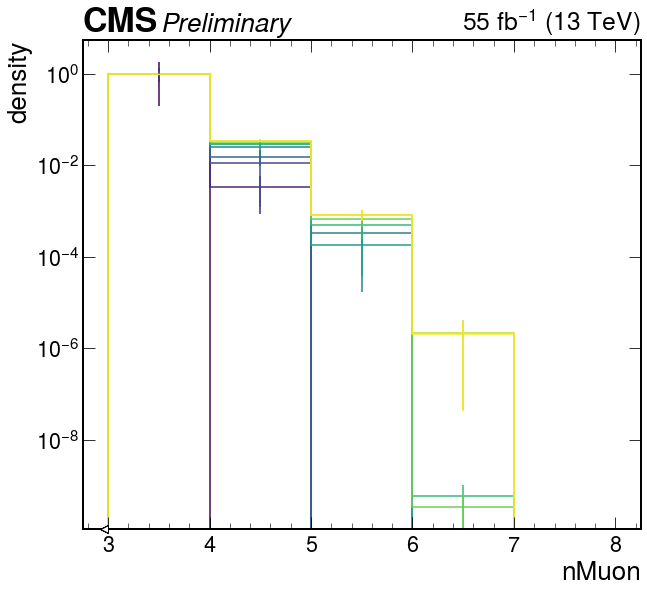

In [97]:
process = 'QCD_Pt_MuEnriched_2018'

N = 10
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.viridis(np.linspace(0,1,N)))

histogram = plots[process]['ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon']

cut = (9.9j, 9.9j, 49j)

fig, ax = plt.subplots(figsize=(10,9))

for i in range(10):
    slc = (i, *cut, slice(None))
    (
        histogram[slc] / histogram[slc].sum().value
    ).plot(
        yerr=np.sqrt(
            histogram[slc].variances() / histogram[slc].sum().value**2
            + histogram[slc].values()**2 * histogram[slc].sum().variance / histogram[slc].sum().value**4
        )
    )
hep.cms.label(llabel="Preliminary", data=True, lumi=55)
plt.yscale('log')
plt.ylabel('density')
plt.show()

## Estimate rate of drop

In [15]:
def muon_func_log(x, loga, logb):
    return loga - x * logb

def make_fit(process, cut=None, logb=None, nBins=None, verbose=False):
    """
    This function will use the loosest available cuts: 
        - ip3d < 0.09, 
        - mini_iso < 9, 
        - neutral_iso < 9,
        - muon_pt < 49,
    and it will fit a power law function: a * b^-n using linear 
    regression on the logarithms. The estimated parameter b is 
    taken as the rate of drop for the given process.
    
    Input: name of the process (should be QCD or DY)
    Output: Minuit fit result
    """
    if cut is None:
        cut = (0.09j, 9j, 49j, slice(None))
    if nBins is not None:
        cut_list = list(cut)
        cut_list[-1] = slice(0, nBins)
        cut = tuple(cut_list)
    histname = 'ip3d_cut_vs_mini_iso_cut_vs_pt_cut_vs_nMuon'
    h0 = plots[process][histname][cut]
    if len(np.where(h0.values() == 0)[0]) == 0:
        first_zero_bin = len(h0.values())
    else:
        first_zero_bin = np.where(h0.values() == 0)[0][0]
    data_x = np.array(list(range(first_zero_bin)))
    data_y = np.log10(h0.values()[:first_zero_bin])
    data_yerr = (np.sqrt(h0.variances()) / (h0.values() * np.log(10)))[:first_zero_bin]
    least_squares = LeastSquares(data_x, data_y, data_yerr, muon_func_log)
    m = Minuit(least_squares, loga=1, logb=1)
    if logb is not None:
        m.fixto('logb', logb)
    m.migrad()
    m.hesse()
    if verbose:
        print(m)
    return m

def evaluate_fit(m):
    """
    This function accepts a Minuit fit result. 
    It will output a histogram that represents an evaluation of the fit
    """
    h0 = hist.Hist.new.Reg(5, 3, 8, name='nMuon', label='nMuon').Weight()
    x = np.arange(3,8)
    logy, logycov = propagate(lambda p: muon_func_log(x - 3, *p), m.values, m.covariance)
    logyerr_prop = np.diag(logycov) ** 0.5
    y = 10**logy
    yerr_prop = np.log(10) * y * logyerr_prop
    for i in range(len(h0.values())):
        h0[i] = (y[i], yerr_prop[i]**2)
    return h0

def plot_fit(process, m, cut=None):
    histname = 'ip3d_cut_vs_mini_iso_cut_vs_pt_cut_vs_nMuon'
    if cut is None:
        cut = (0.09j, 9j, 49j, slice(None))
    else:
        # Make sure the nMuon is not cut
        cut_list = list(cut)
        cut_list[-1] = slice(None)
        cut = tuple(cut_list)

    h0 = plots[process][histname][cut]

    fig = plt.figure(figsize=(12, 12))
    plt.subplots_adjust(bottom=0.15, left=0.17)
    ax1 = plt.subplot2grid((5, 1), (0, 0), rowspan=3)
    ax2 = plt.subplot2grid((5, 1), (3, 0), sharex=ax1)
    ax3 = plt.subplot2grid((5, 1), (4, 0), sharex=ax1)

    x = np.arange(3,8)
    logy, logycov = propagate(lambda p: muon_func_log(x - 3, *p), m.values, m.covariance)
    logyerr_prop = np.diag(logycov) ** 0.5

    y = 10**logy
    yerr_prop = np.log(10) * y * logyerr_prop

    x_hatch = np.vstack(
        (np.arange(3,8), np.arange(4,9))
    ).reshape((-1,), order="F")
    y_hatch = np.vstack(
        (y, y)
    ).reshape((-1,), order="F")
    y_hatch_unc = np.vstack(
        (yerr_prop, yerr_prop)
    ).reshape((-1,), order="F")
    hep.histplot(h0, yerr=np.sqrt(h0.variances()), label="MC", ax=ax1)
    hep.histplot(y, bins=np.arange(3,9), label="fit", ax=ax1)
    ax1.fill_between(
        x=x_hatch,
        y1=y_hatch - y_hatch_unc,
        y2=y_hatch + y_hatch_unc,
        label="Stat. Unc.",
        step="pre",
        facecolor="C1", 
        alpha=0.3,
        linewidth=0,
    )
    ax1.legend()
    ax1.set_yscale('log')
    ax1.set_xlabel("")
    ax1.set_ylabel("Events")
    ax1.set_xlim(2.8, 8.2)
    #ax1.axes.xaxis.set_ticklabels([])
    #ax1.set_xticklabels([])
    
    ratio = h0.values() / y
    ratio_err = np.sqrt(
        (y ** -2) * (h0.variances())
        + (h0.values() ** 2 * y ** -4)
        * (yerr_prop ** 2)
    )
    ax2.errorbar(
        h0.axes.centers[0],
        ratio,
        yerr=ratio_err,
        color="black",
        fmt="o",
        linestyle="none",
    )
    ax2.axhline(1, ls="--", color="gray")
    ax2.set_xlabel("")
    ax2.set_ylabel("MC / fit")
    ax2.set_xlim(2.8, 8.2)
    ax2.set_ylim(0, 2)
    #ax2.set_xticklabels([])
    
    pulls = (h0.values() - y) / np.sqrt(h0.variances())
    pulls_up = np.where(pulls >= 0, pulls, 0)
    pulls_down = np.where(pulls < 0, pulls, 0)

    x_hatch = np.vstack(
        (np.arange(3,8), np.arange(4,9))
    ).reshape((-1,), order="F")
    y_hatch_up = np.vstack(
        (pulls_up, pulls_up)
    ).reshape((-1,), order="F")
    y_hatch_down = np.vstack(
        (pulls_down, pulls_down)
    ).reshape((-1,), order="F")

    ax3.fill_between(
        x=x_hatch,
        y1=0,
        y2=y_hatch_up,
        step="pre",
        facecolor="None",
        edgecolor="red", 
        alpha=1,
        linewidth=0,
        hatch="///",
    )
    ax3.fill_between(
        x=x_hatch,
        y1=0,
        y2=y_hatch_down,
        step="pre",
        facecolor="None",
        edgecolor="blue", 
        alpha=1,
        linewidth=0,
        hatch="///",
    )

    ax3.set_xlabel("nMuon")
    ax3.set_ylabel("pull")
    ax3.set_xlim(2.8, 8.2)
    ax3.set_ylim(-2.5, 2.5)
    
    temp = ax1.get_xticklabels()
    #ax1.set_xticklabels([])
    ax3.set_xticklabels(temp)
    
    plt.show()

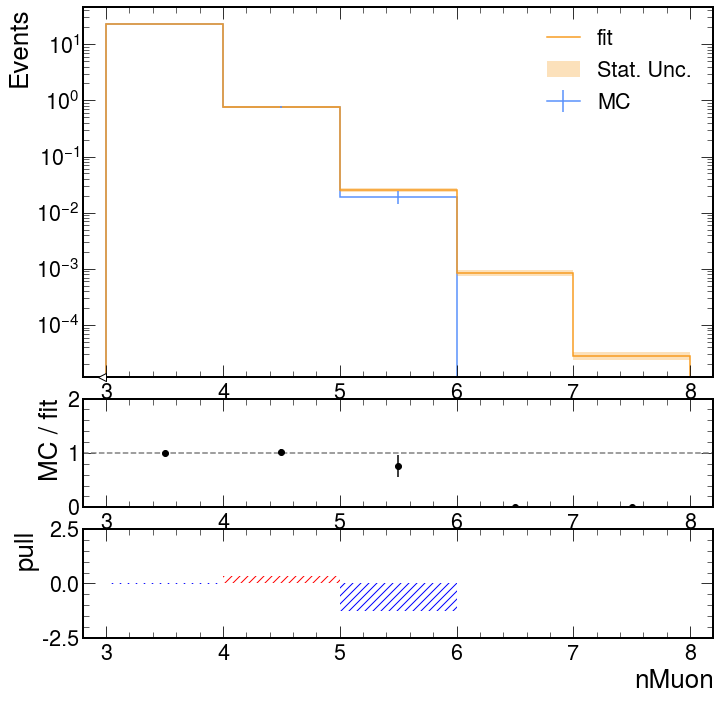

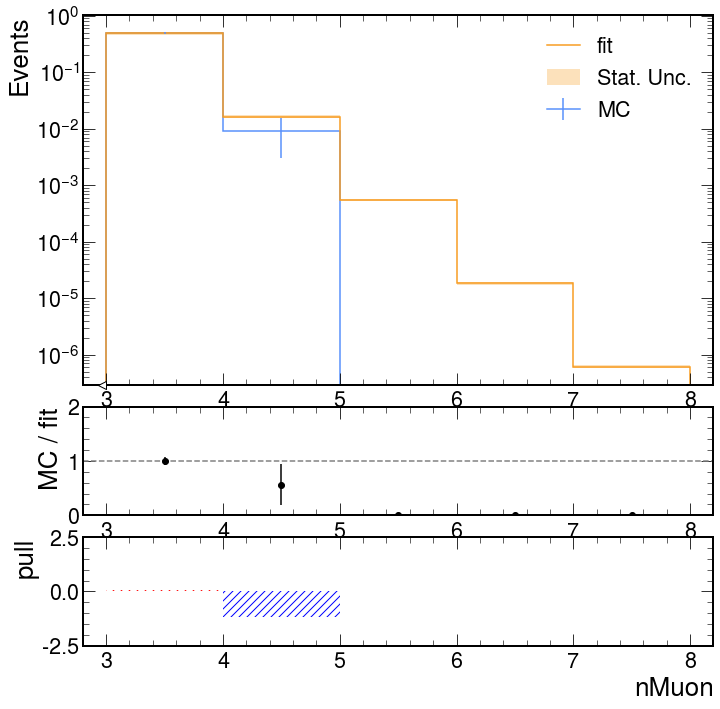

In [17]:
# First, run fit on a very loose cut to get rate of drop
m = make_fit("QCD_Pt_MuEnriched_2018", logb=None, verbose=False)
plot_fit(process="QCD_Pt_MuEnriched_2018", m=m)
# Then, rerun fit on the tight cut fixing the rate of drop
tight_cut = (0.007j, 1j, 35j, slice(None))
m = make_fit("QCD_Pt_MuEnriched_2018", cut=tight_cut, logb=m.values['logb'], nBins=2, verbose=False)
plot_fit(process="QCD_Pt_MuEnriched_2018", m=m, cut=tight_cut)

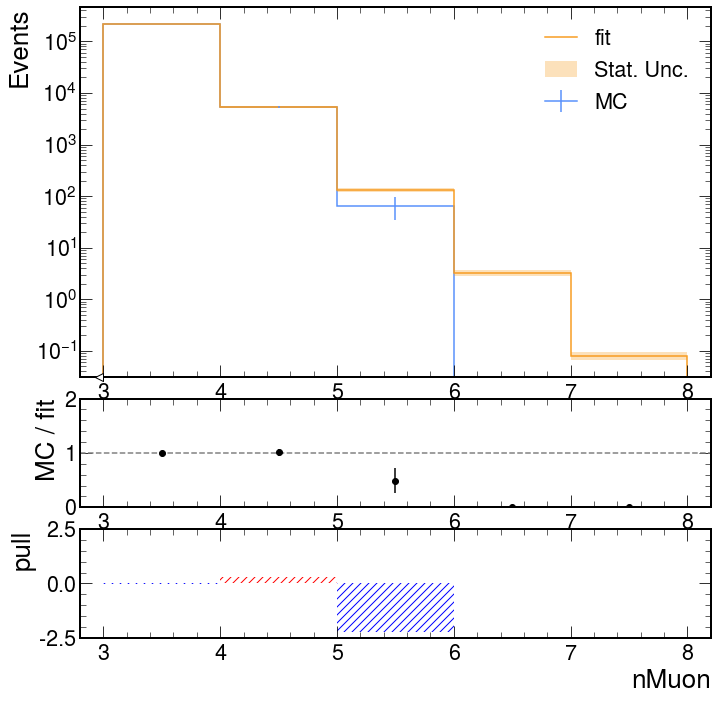

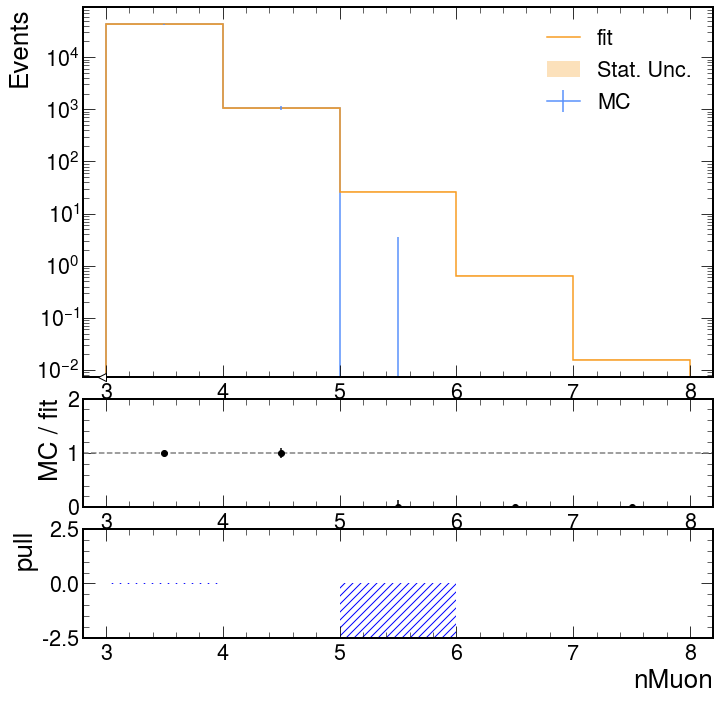

WeightedSum(value=0.659007, variance=0.000164628)

In [35]:
# First, run fit on a very loose cut to get rate of drop
m = make_fit("DY_2018", logb=None, verbose=False)
plot_fit(process="DY_2018", m=m)
# Then, rerun fit on the tight cut fixing the rate of drop
tight_cut = (0.007j, 1j, 35j, slice(None))
m = make_fit("DY_2018", cut=tight_cut, logb=m.values['logb'], nBins=2, verbose=False)
plot_fit(process="DY_2018", m=m, cut=tight_cut)
evaluate_fit(m)[6j::sum]

In [71]:
plots['DY_2018']

{'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon': Hist(
   Regular(10, 0.001, 0.1, transform=log, name='ip3d_cut'),
   Regular(10, 0.1, 10, transform=log, name='mini_iso_cut'),
   Regular(10, 0.1, 10, transform=log, name='neutral_iso_cut'),
   Regular(10, 25, 50, name='pt_cut'),
   Regular(5, 3, 8, name='nMuon'),
   storage=Weight()) # Sum: WeightedSum(value=5.60817e+08, variance=9.87081e+09) (WeightedSum(value=4.71613e+09, variance=6.21566e+10) with flow)}

Scan over ip3d

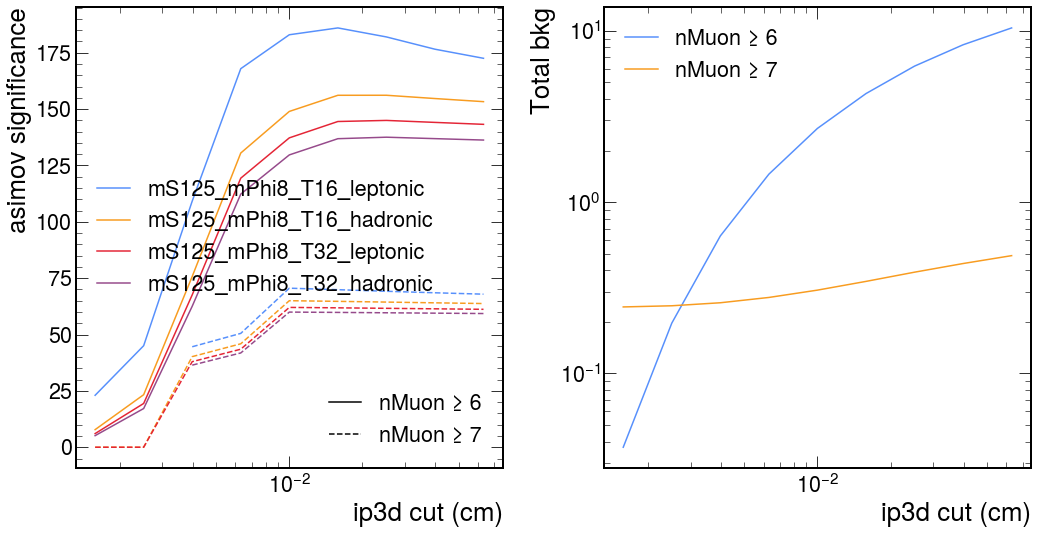

In [20]:
# Now do a full B prediction
histname = 'ip3d_cut_vs_mini_iso_cut_vs_pt_cut_vs_nMuon'
mc_processes = [
    'Other_2018',
    'VV_2018',
    'DY_2018',
    'TT_powheg_2018',
    'QCD_Pt_MuEnriched_2018'
]
signal_processes = [
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
]

tight_cut = (0.01j, 0.8j, 40j, slice(None))
    
hist_bkg_total = None

# First, run fit on a very loose cut to get rate of drop
m_loose_qcd = make_fit("QCD_Pt_MuEnriched_2018", logb=None, verbose=False)
m_loose_dy = make_fit("DY_2018", logb=None, verbose=False)

ip3d_cut_values = plots[mc_processes[0]][histname].axes[0].edges[1:10]

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(15, 8))

for i_sp, sp in enumerate(signal_processes):
    for nMuon_cut in [6j, 7j]:
        tot_B_values = []
        asimov_sig_values = []
        for ip3d_cut in range(1, 10):
            tight_cut = (ip3d_cut, 0.8j, 40j, slice(None))
            for process in mc_processes:
                h_mc = plots[process][histname][tight_cut]
                if "QCD" in process:
                    # Then, rerun fit on the tight cut fixing the rate of drop
                    m_tight_qcd = make_fit(
                        "QCD_Pt_MuEnriched_2018", 
                        cut=tight_cut, 
                        logb=m_loose_qcd.values['logb'], 
                        nBins=2, 
                        verbose=False
                    )
                    h_mc = evaluate_fit(m_tight_qcd)
                elif "DY" in process:
                    # Then, rerun fit on the tight cut fixing the rate of drop
                    m_tight_dy = make_fit(
                        "DY_2018", cut=tight_cut, logb=m_loose_dy.values['logb'], nBins=2, verbose=False
                    )
                    h_mc = evaluate_fit(m_tight_dy)
                if hist_bkg_total is None:
                    hist_bkg_total = h_mc.copy()
                else:
                    hist_bkg_total += h_mc.copy()
            # Tot B
            B = hist_bkg_total[nMuon_cut::sum]
            tot_B_values.append(B.value)

            h_S = plots['GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018'][histname][tight_cut]
            S = h_S[nMuon_cut::sum]
            asimov_sig_values.append(
                ROOT.RooStats.AsimovSignificance(
                    S.value, B.value, np.sqrt(B.variance)*1.5
                )
            )
        
        if i_sp == 0:
            axs[1].plot(ip3d_cut_values, tot_B_values, label=f'nMuon ≥ {nMuon_cut}'.replace('j',''))
            
        ls = '-'
        label = sp.replace('GluGluToSUEP_', '').replace('.000', '').replace('_13TeV_2018', '').replace('mode', '')
        if nMuon_cut == 7j:
            ls = '--'
            label = None
        axs[0].plot(
            ip3d_cut_values, 
            asimov_sig_values, 
            ls=ls, 
            c=f'C{i_sp}', 
            label=label
        )
        
first_legend = axs[0].legend()
axs[0].add_artist(first_legend)
line2, = axs[0].plot([], [], label="nMuon ≥ 6", c='black', ls='-')
line3, = axs[0].plot([], [], label="nMuon ≥ 7", c='black', ls='--')
second_legend = axs[0].legend(handles=[line2, line3], loc='lower right')
axs[0].set_xlabel('ip3d cut (cm)')
axs[0].set_ylabel('asimov significance')
axs[0].set_xscale('log')

axs[1].legend()
axs[1].set_xlabel('ip3d cut (cm)')
axs[1].set_ylabel('Total bkg')
axs[1].set_yscale('log')
axs[1].set_xscale('log')

plt.tight_layout()
plt.show()

Scan over mini_iso

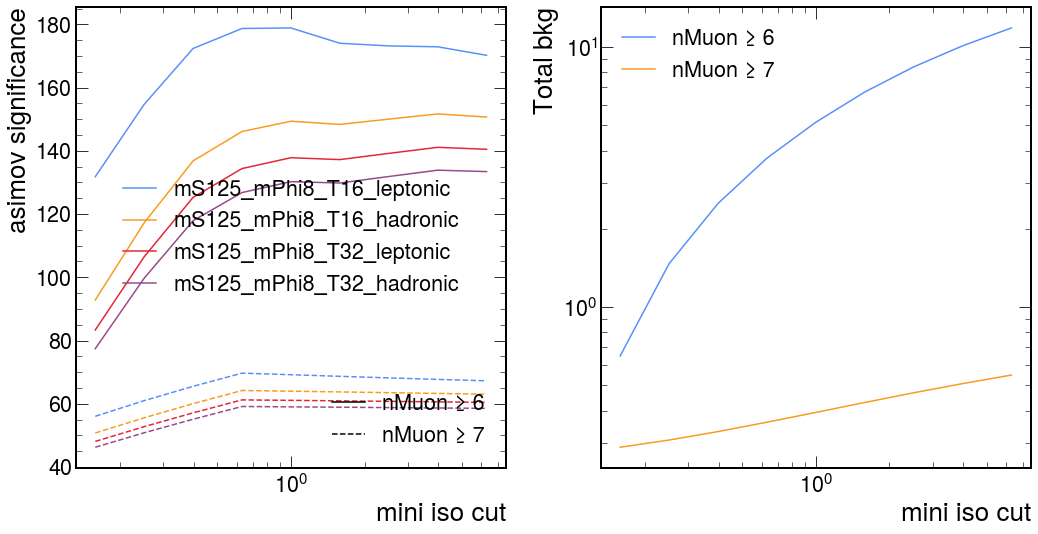

In [24]:
# Now do a full B prediction
histname = 'ip3d_cut_vs_mini_iso_cut_vs_pt_cut_vs_nMuon'
mc_processes = [
    'Other_2018',
    'VV_2018',
    'DY_2018',
    'TT_powheg_2018',
    'QCD_Pt_MuEnriched_2018'
]
signal_processes = [
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
]

tight_cut = (0.01j, 0.8j, 40j, slice(None))
    
hist_bkg_total = None

# First, run fit on a very loose cut to get rate of drop
m_loose_qcd = make_fit("QCD_Pt_MuEnriched_2018", logb=None, verbose=False)
m_loose_dy = make_fit("DY_2018", logb=None, verbose=False)

mini_iso_cut_values = plots[mc_processes[0]][histname].axes[1].edges[1:10]

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(15, 8))

for i_sp, sp in enumerate(signal_processes):
    for nMuon_cut in [6j, 7j]:
        tot_B_values = []
        asimov_sig_values = []
        for mini_iso_cut in range(1, 10):
            tight_cut = (0.01j, mini_iso_cut, 40j, slice(None))
            for process in mc_processes:
                h_mc = plots[process][histname][tight_cut]
                if "QCD" in process:
                    # Then, rerun fit on the tight cut fixing the rate of drop
                    m_tight_qcd = make_fit(
                        "QCD_Pt_MuEnriched_2018", 
                        cut=tight_cut, 
                        logb=m_loose_qcd.values['logb'], 
                        nBins=2, 
                        verbose=False
                    )
                    h_mc = evaluate_fit(m_tight_qcd)
                elif "DY" in process:
                    # Then, rerun fit on the tight cut fixing the rate of drop
                    m_tight_dy = make_fit(
                        "DY_2018", cut=tight_cut, logb=m_loose_dy.values['logb'], nBins=2, verbose=False
                    )
                    h_mc = evaluate_fit(m_tight_dy)
                if hist_bkg_total is None:
                    hist_bkg_total = h_mc.copy()
                else:
                    hist_bkg_total += h_mc.copy()
            # Tot B
            B = hist_bkg_total[nMuon_cut::sum]
            tot_B_values.append(B.value)

            h_S = plots['GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018'][histname][tight_cut]
            S = h_S[nMuon_cut::sum]
            asimov_sig_values.append(
                ROOT.RooStats.AsimovSignificance(
                    S.value, B.value, np.sqrt(B.variance)*1.5
                )
            )
        
        if i_sp == 0:
            axs[1].plot(mini_iso_cut_values, tot_B_values, label=f'nMuon ≥ {nMuon_cut}'.replace('j',''))
            
        ls = '-'
        label = sp.replace('GluGluToSUEP_', '').replace('.000', '').replace('_13TeV_2018', '').replace('mode', '')
        if nMuon_cut == 7j:
            ls = '--'
            label = None
        axs[0].plot(
            mini_iso_cut_values, 
            asimov_sig_values, 
            ls=ls, 
            c=f'C{i_sp}', 
            label=label
        )
        
first_legend = axs[0].legend()
axs[0].add_artist(first_legend)
line2, = axs[0].plot([], [], label="nMuon ≥ 6", c='black', ls='-')
line3, = axs[0].plot([], [], label="nMuon ≥ 7", c='black', ls='--')
second_legend = axs[0].legend(handles=[line2, line3], loc='lower right')
axs[0].set_xlabel('mini iso cut')
axs[0].set_ylabel('asimov significance')
axs[0].set_xscale('log')

axs[1].legend()
axs[1].set_xlabel('mini iso cut')
axs[1].set_ylabel('Total bkg')
axs[1].set_yscale('log')
axs[1].set_xscale('log')

plt.tight_layout()
plt.show()

Scan over pt cut

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.456 (χ²/ndof = 2.5)      │              Nfcn = 47               │
│ EDM = 9.72e-21 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ loga │   5.337   │   0.004   │            │            │         │         │       │
│ 1 │ logb │   1.607   │   0.020   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────┬───────────────────┐
│      │     loga     logb │
├──────┼───────────────────┤
│ loga │ 1.37e-05 0.013e-3 │
│ logb │ 0.013e-3 0.000393 │
└──────┴───────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0                          │              Nfcn = 91               │
│ EDM = 0 (Goal: 0.0002)           │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│           Hesse FAILED           │       Covariance NOT pos. def.       │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ loga │     1     │     0     │            │            │         │         │       │
│ 1 │ logb │   1.607   │   0.010   │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘

TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'

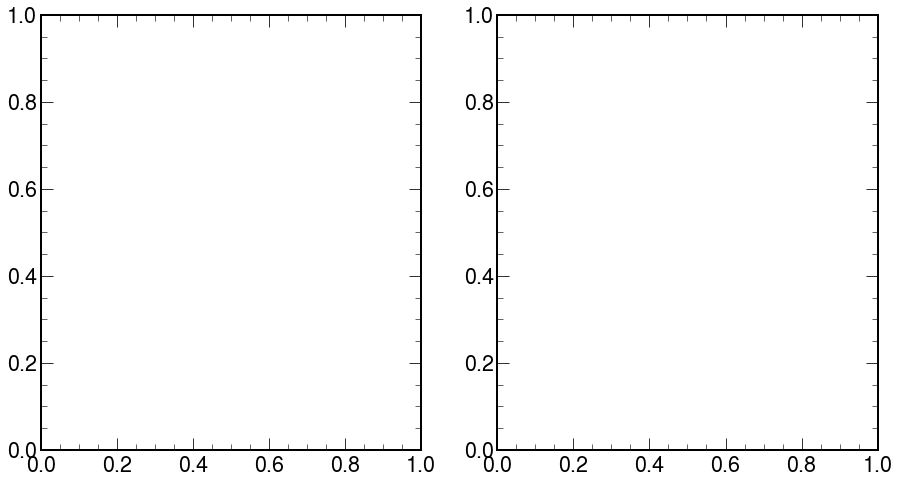

In [42]:
# Now do a full B prediction
histname = 'ip3d_cut_vs_mini_iso_cut_vs_pt_cut_vs_nMuon'
mc_processes = [
    'Other_2018',
    'VV_2018',
    'DY_2018',
    'TT_powheg_2018',
    'QCD_Pt_MuEnriched_2018'
]
signal_processes = [
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
]

tight_cut = (0.01j, 0.8j, 40j, slice(None))
    
hist_bkg_total = None

# First, run fit on a very loose cut to get rate of drop
m_loose_qcd = make_fit("QCD_Pt_MuEnriched_2018", logb=None, verbose=False)
m_loose_dy = make_fit("DY_2018", logb=None, verbose=False)

print(m_loose_dy)

pt_cut_values = plots[mc_processes[0]][histname].axes[2].edges[1:10]

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(15, 8))

for i_sp, sp in enumerate(signal_processes):
    for nMuon_cut in [6j, 7j]:
        tot_B_values = []
        asimov_sig_values = []
        for pt_cut in range(1, 10):
            tight_cut = (0.01j, 0.8j, pt_cut, slice(None))
            for process in mc_processes:
                h_mc = plots[process][histname][tight_cut]
                if "QCD" in process:
                    # Then, rerun fit on the tight cut fixing the rate of drop
                    m_tight_qcd = make_fit(
                        "QCD_Pt_MuEnriched_2018", 
                        cut=tight_cut, 
                        logb=m_loose_qcd.values['logb'], 
                        nBins=2, 
                        verbose=False
                    )
                    h_mc = evaluate_fit(m_tight_qcd)
                elif "DY" in process:
                    # Then, rerun fit on the tight cut fixing the rate of drop
                    m_tight_dy = make_fit(
                        "DY_2018", cut=tight_cut, logb=m_loose_dy.values['logb'], nBins=1, verbose=False
                    )
#                     j = 1
#                     while (not m_tight_dy.valid) and (j > 0):
#                         m_tight_dy = make_fit(
#                             "DY_2018", cut=tight_cut, logb=m_loose_dy.values['logb'], nBins=j, verbose=False
#                         )
#                         j -= 1
                        
                    print(m_tight_dy)
                    h_mc = evaluate_fit(m_tight_dy)
                if hist_bkg_total is None:
                    hist_bkg_total = h_mc.copy()
                else:
                    hist_bkg_total += h_mc.copy()
            # Tot B
            B = hist_bkg_total[nMuon_cut::sum]
            tot_B_values.append(B.value)

            h_S = plots['GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018'][histname][tight_cut]
            S = h_S[nMuon_cut::sum]
            asimov_sig_values.append(
                ROOT.RooStats.AsimovSignificance(
                    S.value, B.value, np.sqrt(B.variance)*1.5
                )
            )
        
        if i_sp == 0:
            axs[1].plot(pt_cut_values, tot_B_values, label=f'nMuon ≥ {nMuon_cut}'.replace('j',''))
            
        ls = '-'
        label = sp.replace('GluGluToSUEP_', '').replace('.000', '').replace('_13TeV_2018', '').replace('mode', '')
        if nMuon_cut == 7j:
            ls = '--'
            label = None
        axs[0].plot(
            pt_cut_values, 
            asimov_sig_values, 
            ls=ls, 
            c=f'C{i_sp}', 
            label=label
        )
        
first_legend = axs[0].legend()
axs[0].add_artist(first_legend)
line2, = axs[0].plot([], [], label="nMuon ≥ 6", c='black', ls='-')
line3, = axs[0].plot([], [], label="nMuon ≥ 7", c='black', ls='--')
second_legend = axs[0].legend(handles=[line2, line3], loc='lower right')
axs[0].set_xlabel('pt cut')
axs[0].set_ylabel('asimov significance')

axs[1].legend()
axs[1].set_xlabel('pt cut')
axs[1].set_ylabel('Total bkg')
axs[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [40]:
m_tight_dy.valid

False

In [37]:
data_yerr

array([212134.03174917,  36722.51186398,   3383.98539441,     30.52957837])

In [55]:
def pred(h_in, offset=0):
    # Use bins offset, offset+1 to guess the function. Defaults to 0, 1.
    f0 = h_in.values()[offset]
    f1 = h_in.values()[1+offset]
    var_f0 = h_in.variances()[offset]
    var_f1 = h_in.variances()[1+offset]
    values = [f1 * (f1 / f0)**(n - 1) for n in range(len(h_in.values()))]
    variances = [
        (
            ((n - 1) * (f1 / f0)**n)**2 * var_f0 + (n * (f1 / f0)**(n - 1))**2 * var_f1
        ) for n in range(len(h_in.values()))
    ]
    h_out = h_in.copy().reset()
    for i in range(len(h_in.values())):
        h_out[i] = (values[i], variances[i])
    return h_out

In [66]:
def pred_new(h_in, B, var_B):
    f0 = h_in.values()[0]
    var_f0 = h_in.variances()[0]
    values = [f0 * B**(-n) for n in range(len(h_in.values()))]
    variances = [
        (
            B**(- 2 * n) * var_f0 + (n * B**(- n - 1) * f0)**2 * var_B
        ) for n in range(len(h_in.values()))
    ]
    h_out = h_in.copy().reset()
    for i in range(len(h_in.values())):
        h_out[i] = (values[i], variances[i])
    return h_out

In [57]:
hep.style.use(hep.style.CMS)

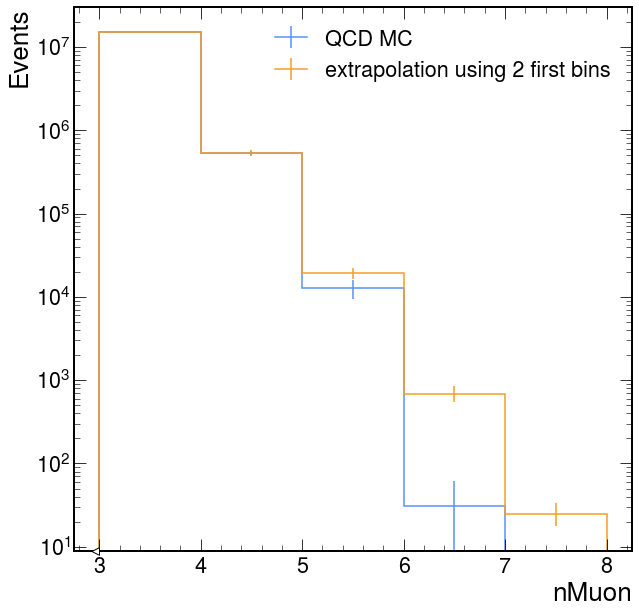

707.6257 ± 142.2537

[ 1.          1.          1.49625648 21.89389129         inf]

[ 0.02005544  0.09712591  0.44699477 21.89847564         nan]

In [59]:
h = plots['QCD_Pt_MuEnriched_2018'][
    'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon'
][0.09j, 9j, 9j, 49j, :]

h.plot(yerr=np.sqrt(h.variances()), label='QCD MC')
pred(h).plot(label='extrapolation using 2 first bins')
plt.ylabel('Events')
plt.yscale('log')
#plt.ylim(1e-4, 1e7)
plt.legend()
plt.show()

print(f"{pred(h)[6j::sum].value:.4f} ± {np.sqrt(pred(h)[6j::sum].variance):.4f}")

print(pred(h).values() / h.values())
print(np.sqrt(pred(h).variances() / (h.values()**2) + pred(h).values()**2 * h.variances() / (h.values()**4)))

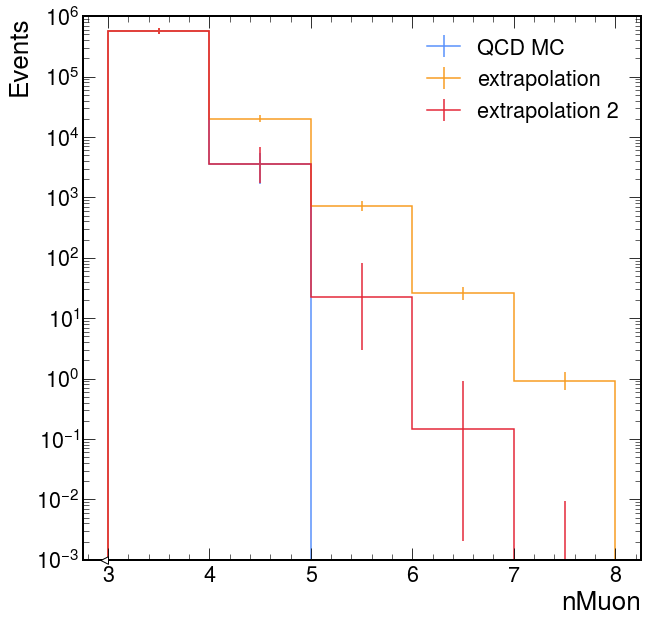

In [73]:
h_loose = plots['QCD_Pt_MuEnriched_2018'][
    'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon'
][0.09j, 9j, 9j, 49j, :]
B = h_loose[0].value / h_loose[1].value
var_B = (
    h_loose[0].variance / h_loose[1].value**2 
    + (h_loose[0].value**2 / h_loose[1].value**4) * h_loose[1].variance
)

h = plots['QCD_Pt_MuEnriched_2018'][
    'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon'
][0.011j, 1.01j, 0.101j, 35.01j, :]

h.plot(yerr=np.sqrt(h.variances()), label='QCD MC')
pred_new(h, B, var_B).plot(label='extrapolation')
pred(h).plot(label='extrapolation 2')
plt.ylabel('Events')
plt.ylim(1e-3, 1e6)
plt.yscale('log')
plt.legend()
plt.show()

# print(f"{pred_new(h)[6j::sum].value:.4f} ± {np.sqrt(pred_new(h)[6j::sum].variance):.4f}")

# print(pred(h).values() / h.values())
# print(np.sqrt(pred(h).variances() / (h.values()**2) + pred(h).values()**2 * h.variances() / (h.values()**4)))

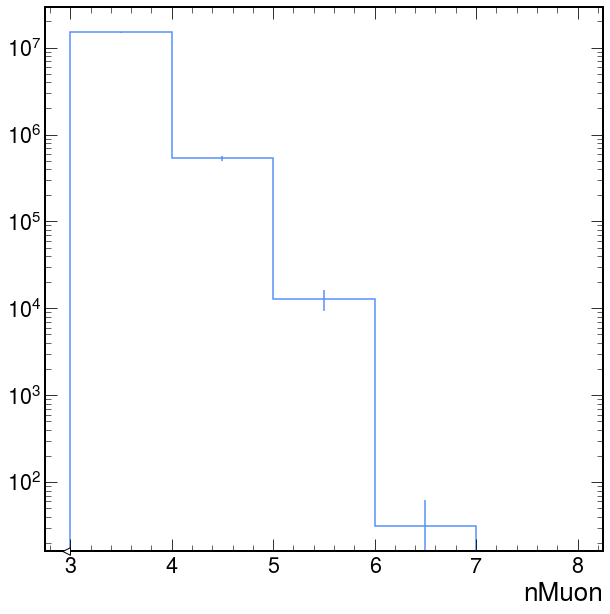

In [41]:
histogram = plots['QCD_Pt_MuEnriched_2018']['ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon']

cuts = [
    (0.09j, 9j, 9j, 49j, slice(None)),
]

for cut in cuts:
    histogram[cut].plot(
        yerr=np.sqrt(histogram[cut].variances())
    )
plt.yscale('log')
plt.show()

In [12]:
import ROOT

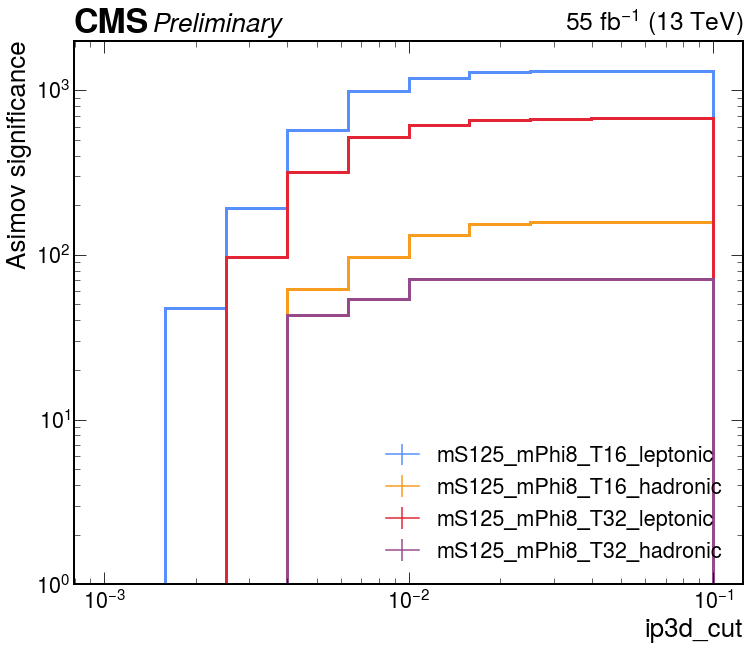

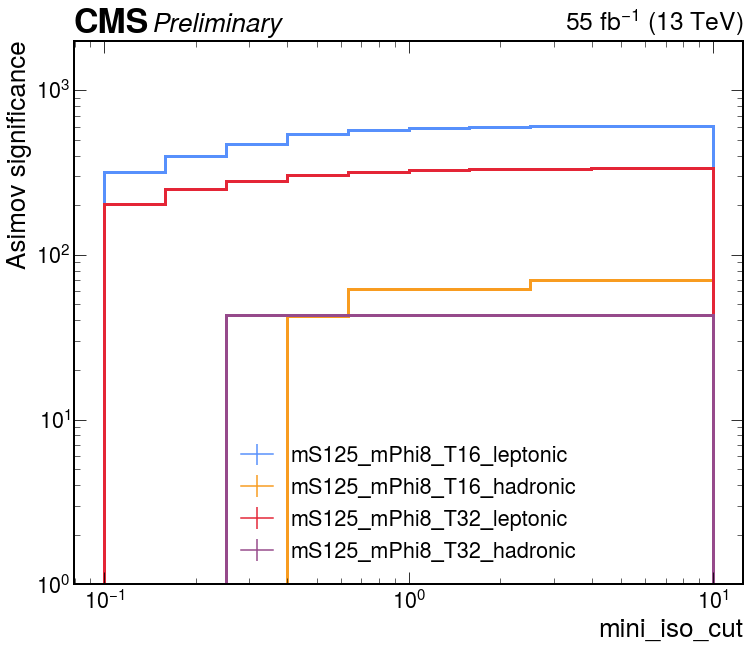

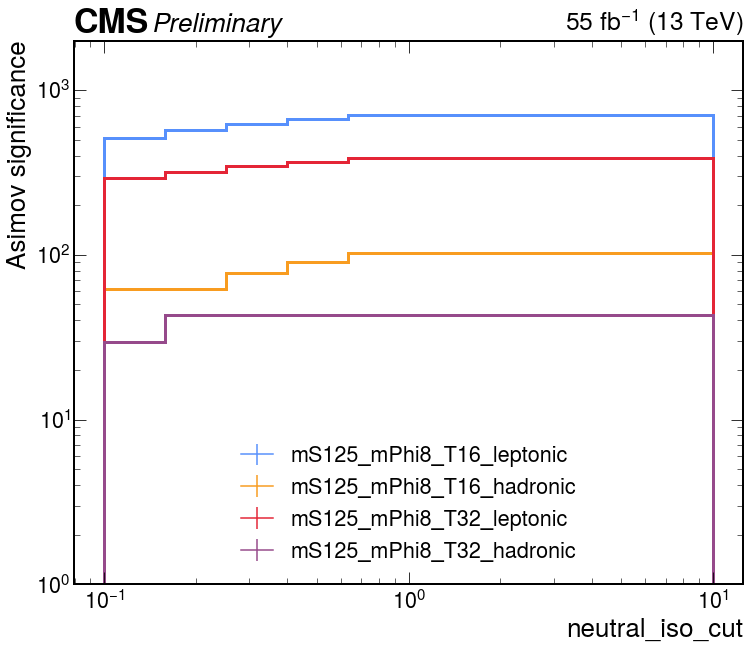

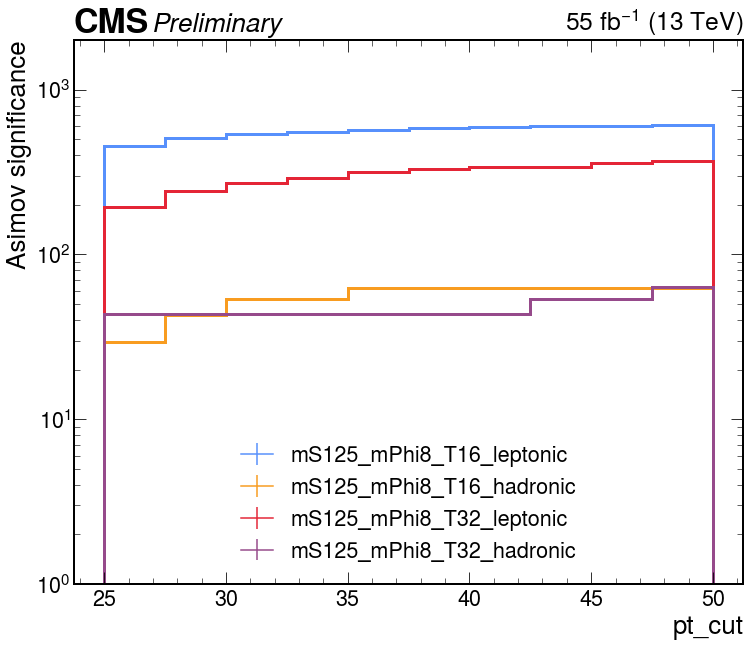

In [14]:
mc_processes = [
    'Other_2018',
    'VV_2018',
    'DY_2018',
    'TT_powheg_2018',
    'QCD_Pt_MuEnriched_2018'
]
mc_labels = [
    'Other',
    'VV',
    'DY',
    'TT',
    'QCD'
]

signal_processes = [
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T16.000_modehadronic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modeleptonic_13TeV_2018',
    'GluGluToSUEP_mS125.000_mPhi8.000_T32.000_modehadronic_13TeV_2018',
]
signal_labels = [
    'mS125_mPhi8_T16_leptonic',
    'mS125_mPhi8_T16_hadronic',
    'mS125_mPhi8_T32_leptonic',
    'mS125_mPhi8_T32_hadronic',    
]

histname = 'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon'

# Begin using the starting point: 
#default_cut = (0.1j*0.99, 10j*0.99, 10j*0.99, 50j*0.99)
default_cut = (0.006j, 1j, 0.2j, 35j)

cuts = [
    (slice(None), default_cut[1], default_cut[2], default_cut[3], slice(7j, None, sum)),
    (default_cut[0], slice(None), default_cut[2], default_cut[3], slice(7j, None, sum)),
    (default_cut[0], default_cut[1], slice(None), default_cut[3], slice(7j, None, sum)),
    (default_cut[0], default_cut[1], default_cut[2], slice(None), slice(7j, None, sum)),
]

for j, slc in enumerate(cuts):
    hist_bkg_total = None

    for process in mc_processes:
        h_mc = plots[process][histname][slc]
        # Here I could feed h_mc to the prediction function
#         if 
#         if "QCD" in process:
#             h_mc = pred(h_mc, offset=0)
#         elif "DY" in process:
#             h_mc = pred(h_mc, offset=1)
        if hist_bkg_total is None:
            hist_bkg_total = h_mc.copy()
        else:
            hist_bkg_total += h_mc.copy()

    significances = []
    for process in signal_processes:
        h_s = plots[process][histname][slc]
        h_sig = h_s.copy()
        for i in range(len(h_sig.values())):
            tot_bkg = hist_bkg_total[i].value
            tot_bkg_var = hist_bkg_total[i].value
            if tot_bkg == 0:
                tot_bkg = 1e-3
#             if tot_bkg_var == 0:
#                 tot_bkg_var = 1e-3

            h_sig[i] = (
                ROOT.RooStats.AsimovSignificance(h_s[i].value, tot_bkg, np.sqrt(tot_bkg_var)*1.3), 0
            )
        significances.append(h_sig)

    fig, ax = plt.subplots(figsize=(12,10))

    hep.histplot(
        significances, 
        label=signal_labels,        
        lw=3,
        ax=ax,
    )

    hep.cms.label(llabel="Preliminary", data=True, lumi=55, ax=ax)
    plt.ylim(1, 2e3)
    if hist_bkg_total.axes[0].name != "pt_cut":
        ax.set_xscale('log')
    ax.set_yscale('log')
    plt.legend()
    plt.ylabel("Asimov significance")
    plt.show()

In [80]:
hist_bkg_total.axes[0].name

'pt_cut'

## Evaluate final cuts

In [30]:
tight_cut = (0.008j, 0.65j, 49j, slice(None))

In [33]:
[ax.edges for ax in plots['DY_2018']['ip3d_cut_vs_mini_iso_cut_vs_pt_cut_vs_nMuon'].axes]

[array([0.001     , 0.00158489, 0.00251189, 0.00398107, 0.00630957,
        0.01      , 0.01584893, 0.02511886, 0.03981072, 0.06309573,
        0.1       ]),
 array([ 0.1       ,  0.15848932,  0.25118864,  0.39810717,  0.63095734,
         1.        ,  1.58489319,  2.51188643,  3.98107171,  6.30957344,
        10.        ]),
 array([25. , 27.5, 30. , 32.5, 35. , 37.5, 40. , 42.5, 45. , 47.5, 50. ]),
 array([3., 4., 5., 6., 7., 8.])]

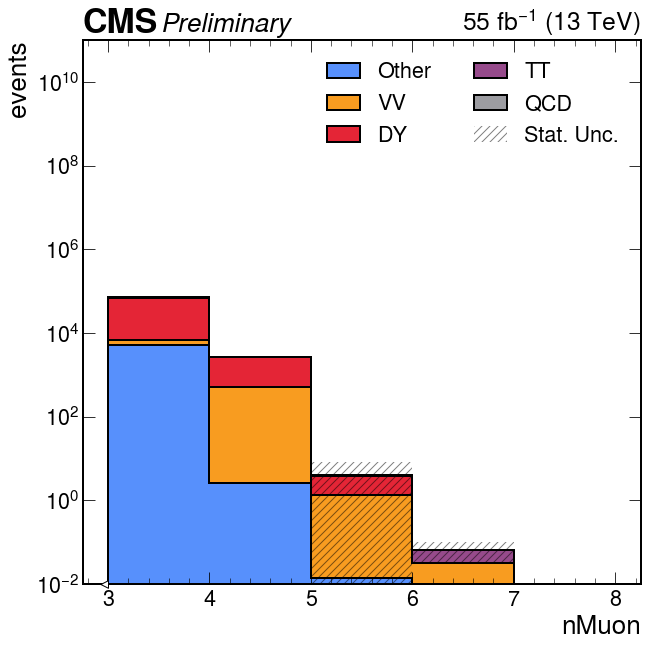

In [32]:
# Pre-fit
histname = 'ip3d_cut_vs_mini_iso_cut_vs_pt_cut_vs_nMuon'
mc_processes = [
    'Other_2018',
    'VV_2018',
    'DY_2018',
    'TT_powheg_2018',
    'QCD_Pt_MuEnriched_2018'
]
mc_labels = [
    'Other',
    'VV',
    'DY',
    'TT',
    'QCD'
]
    
hist_bkg_total = None

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(10, 10))

h_bkg_list = []
for process in mc_processes:
    h_mc = plots[process][histname][tight_cut]
    h_bkg_list.append(h_mc)
    if hist_bkg_total is None:
        hist_bkg_total = h_mc.copy()
    else:
        hist_bkg_total += h_mc.copy()

hep.histplot(
    h_bkg_list, 
    stack=True, 
    label=mc_labels,        
    histtype="fill",
    ec="black",
    lw=2,
    ax=ax,
)

x_hatch = np.vstack(
    (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
).reshape((-1,), order="F")
y_hatch1 = np.vstack((hist_bkg_total.values(), hist_bkg_total.values())).reshape(
    (-1,), order="F"
)
y_hatch1_unc = np.vstack(
    (np.sqrt(hist_bkg_total.variances()), np.sqrt(hist_bkg_total.variances()))
).reshape((-1,), order="F")
ax.fill_between(
    x=x_hatch,
    y1=y_hatch1 - y_hatch1_unc,
    y2=y_hatch1 + y_hatch1_unc,
    label="Stat. Unc.",
    step="pre",
    facecolor="none",
    edgecolor=(0, 0, 0, 0.5),
    linewidth=0,
    hatch="///",
    zorder=2,
)

hep.cms.label(llabel="Preliminary", data=True, lumi=55, ax=ax)
plt.ylim(1e-2, 1e11)
plt.yscale('log')
plt.legend(ncol=2)
plt.xlabel("nMuon")
plt.ylabel("events")
plt.show()

Other_2018: 0.000 ± 0.000

VV_2018: 0.000 ± 0.000

DY_2018: 0.034 ± 0.001

TT_powheg_2018: 0.000 ± 0.000

QCD_Pt_MuEnriched_2018: 0.369 ± 0.042

tot bkg: 0.403 ± 0.042

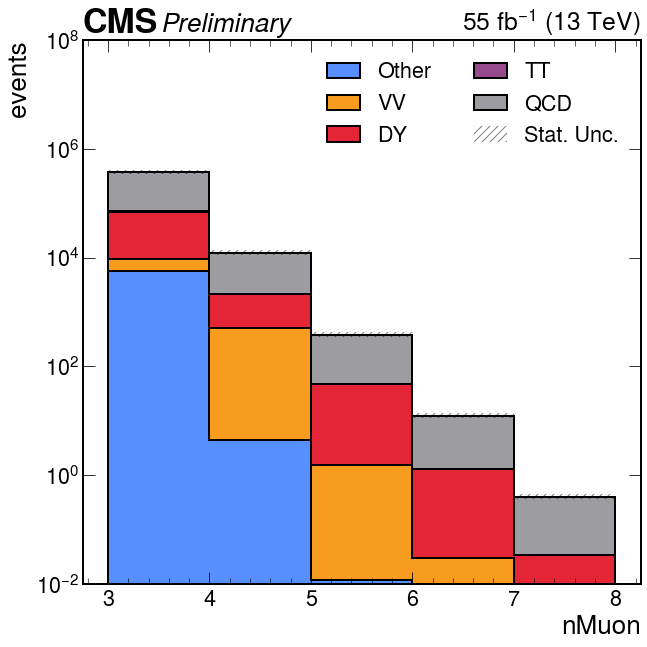

In [73]:
histname = 'ip3d_cut_vs_mini_iso_cut_vs_neutral_iso_cut_vs_pt_cut_vs_nMuon'
mc_processes = [
    'Other_2018',
    'VV_2018',
    'DY_2018',
    'TT_powheg_2018',
    'QCD_Pt_MuEnriched_2018'
]
mc_labels = [
    'Other',
    'VV',
    'DY',
    'TT',
    'QCD'
]
    
hist_bkg_total = None

# First, run fit on a very loose cut to get rate of drop
m_loose_qcd = make_fit("QCD_Pt_MuEnriched_2018", logb=None, verbose=False)
m_loose_dy = make_fit("DY_2018", logb=None, verbose=False)

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(10, 10))

h_bkg_list = []
for process in mc_processes:
    h_mc = plots[process][histname][tight_cut]
    if "QCD" in process:
        # Then, rerun fit on the tight cut fixing the rate of drop
        m_tight_qcd = make_fit(
            "QCD_Pt_MuEnriched_2018", 
            cut=tight_cut, 
            logb=m_loose_qcd.values['logb'], 
            nBins=2, 
            verbose=False
        )
        h_mc = evaluate_fit(m_tight_qcd)
    elif "DY" in process:
        # Then, rerun fit on the tight cut fixing the rate of drop
        m_tight_dy = make_fit(
            "DY_2018", cut=tight_cut, logb=m_loose_dy.values['logb'], nBins=2, verbose=False
        )
        h_mc = evaluate_fit(m_tight_dy)
    h_bkg_list.append(h_mc)
    print(f"{process}: {h_mc[7j::sum].value:.3f} ± {np.sqrt(h_mc[7j::sum].variance):.3f}")
    if hist_bkg_total is None:
        hist_bkg_total = h_mc.copy()
    else:
        hist_bkg_total += h_mc.copy()
print(f"tot bkg: {hist_bkg_total[7j::sum].value:.3f} ± {np.sqrt(hist_bkg_total[7j::sum].variance):.3f}")

hep.histplot(
    h_bkg_list, 
    stack=True, 
    label=mc_labels,        
    histtype="fill",
    ec="black",
    lw=2,
    ax=ax,
)

x_hatch = np.vstack(
    (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
).reshape((-1,), order="F")
y_hatch1 = np.vstack((hist_bkg_total.values(), hist_bkg_total.values())).reshape(
    (-1,), order="F"
)
y_hatch1_unc = np.vstack(
    (np.sqrt(hist_bkg_total.variances()), np.sqrt(hist_bkg_total.variances()))
).reshape((-1,), order="F")
ax.fill_between(
    x=x_hatch,
    y1=y_hatch1 - y_hatch1_unc,
    y2=y_hatch1 + y_hatch1_unc,
    label="Stat. Unc.",
    step="pre",
    facecolor="none",
    edgecolor=(0, 0, 0, 0.5),
    linewidth=0,
    hatch="///",
    zorder=2,
)

hep.cms.label(llabel="Preliminary", data=True, lumi=55, ax=ax)
plt.ylim(1e-2, 1e8)
plt.yscale('log')
plt.legend(ncol=2)
plt.xlabel("nMuon")
plt.ylabel("events")
plt.show()

In [34]:
m_tight_dy

IndexError: index 0 is out of bounds for axis 0 with size 0

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0                          │              Nfcn = 91               │
│ EDM = 0 (Goal: 0.0002)           │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│           Hesse FAILED           │       Covariance NOT pos. def.       │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────